/tmp/ipykernel_45144/2751432198.py:52: RuntimeWarning: invalid value encountered in divide
  mean_photons = np.where(muon_count > 0, photon_sum / muon_count, 0).T


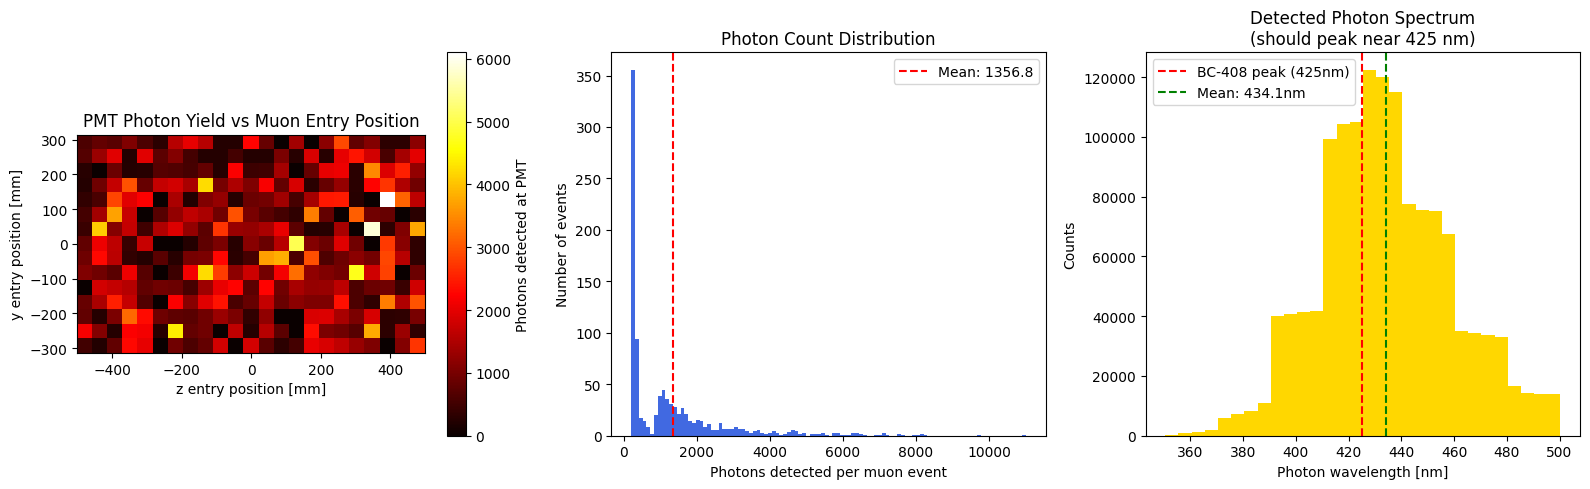

Total muon events:       1000
Events with PMT hits:    1000
Mean photons per muon:   1356.8


In [11]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

FILE_PATH = "/home/bjorn/g4_work/g4work_project/scintilator/production/energy_sweep_mu-_1MeV_to_100GeV_nevents1000/scoring_e1p3060MeV.root"

# ── Load data ─────────────────────────────────────────────
with uproot.open(FILE_PATH) as f:
    # Muon entry positions
    muon  = f["MuonEntry"]
    z_entry = muon["z_entry"].array(library="np")
    y_entry = muon["y_entry"].array(library="np")
    ev_muon = muon["EvID"].array(library="np")

    # Photon hits on PMT
    hits  = f["PhotonHits"]
    y_hit   = hits["y_hit"].array(library="np")
    energy  = hits["energy"].array(library="np")
    ev_hits = hits["EvID"].array(library="np")


# ── Count photons per event ────────────────────────────────
# For each muon event, count how many photon hits it produced
unique_events, photon_counts = np.unique(ev_hits, return_counts=True)

# Map counts back to muon entry positions
# Events with zero photons won't appear in hits — fill with 0
count_map = dict(zip(unique_events, photon_counts))
counts_per_muon = np.array([count_map.get(ev, 0) for ev in ev_muon])

# ── Plot 1: Heatmap of photon yield vs muon entry position ─
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Normalized heatmap ─────────────────────────────────────
n_bins_y = 15          # 628 mm direction
n_bins_z = int(n_bins_y * (1000/628))         # 1000 mm direction — scaled: 20 * (1000/628) ≈ 32
y_range = [-314, 314]
z_range = [-500, 500]

photon_sum, z_edges, y_edges = np.histogram2d(
    z_entry, y_entry,
    bins=[n_bins_z, n_bins_y],
    range=[z_range, y_range],
    weights=counts_per_muon
)

muon_count, _, _ = np.histogram2d(
    z_entry, y_entry,
    bins=[n_bins_z, n_bins_y],
    range=[z_range, y_range]
)
mean_photons = np.where(muon_count > 0, photon_sum / muon_count, 0).T

im = axes[0].imshow(
    mean_photons,
    origin="lower",
    extent=[z_range[0], z_range[1], y_range[0], y_range[1]],
    aspect="equal",    # now bins are square in mm so equal aspect is correct
    cmap="hot",
    interpolation="nearest"
)

plt.colorbar(im, ax=axes[0], label="Photons detected at PMT")
axes[0].set_xlabel("z entry position [mm]")
axes[0].set_ylabel("y entry position [mm]")
axes[0].set_title("PMT Photon Yield vs Muon Entry Position")

# ── Plot 2: Photon count distribution ──────────────────────
axes[1].hist(counts_per_muon, bins=int(np.sqrt(max(counts_per_muon))), color="royalblue", linewidth=0.5)
axes[1].set_xlabel("Photons detected per muon event")
axes[1].set_ylabel("Number of events")
axes[1].set_title("Photon Count Distribution")
axes[1].axvline(np.mean(counts_per_muon), color="red",
                linestyle="--", label=f"Mean: {np.mean(counts_per_muon):.1f}")
axes[1].legend()

# ── Plot 3: Photon energy spectrum ─────────────────────────
# Convert eV to nm for readability: λ = hc/E
wavelength = (4.136e-15 * 3e8) / (energy * 1e6) * 1e9  # rough, in nm
axes[2].hist(wavelength, bins=30, color="gold", linewidth=0.5)
axes[2].set_xlabel("Photon wavelength [nm]")
axes[2].set_ylabel("Counts")
axes[2].set_title("Detected Photon Spectrum\n(should peak near 425 nm)")
axes[2].axvline(425, color="red", linestyle="--", label="BC-408 peak (425nm)")
axes[2].axvline(np.mean(wavelength), color="green",
                linestyle="--", label=f"Mean: {np.mean(wavelength):.1f}nm")
axes[2].legend()

plt.tight_layout()
plt.savefig("scintillator_test.png", dpi=150)
plt.show()

# ── Sanity check printout ──────────────────────────────────
print(f"Total muon events:       {len(ev_muon)}")
print(f"Events with PMT hits:    {len(unique_events)}")
print(f"Mean photons per muon:   {np.mean(counts_per_muon):.1f}")
#print(f"Expected (rough):        ~{250*0.002*10000*0.01:.0f}")
# 250MeV muon deposits ~2MeV in 20mm plastic → ~20000 photons
# ~1% reach PMT after reflections/absorption → ~200 expected

In [12]:
# ═══════════════════════════════════════════════════════════════════════════
# PMT RESPONSE — imports + configurable parameters
# ═══════════════════════════════════════════════════════════════════════════
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d
from scipy.constants import h, c, e as e_charge

plt.rcParams.update({
    "figure.facecolor": "#0e1117",
    "axes.facecolor":   "#161b22",
    "axes.edgecolor":   "#30363d",
    "axes.labelcolor":  "#e6edf3",
    "axes.titlecolor":  "#e6edf3",
    "axes.grid":        True,
    "grid.color":       "#21262d",
    "grid.linewidth":   0.8,
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "text.color":       "#e6edf3",
    "legend.facecolor": "#161b22",
    "legend.edgecolor": "#30363d",
    "font.family":      "monospace",
    "font.size":        10,
})

plt.rcParams.update({
    "figure.facecolor":  "#ffffff",   # white figure background
    "axes.facecolor":    "#f6f8fa",   # subtle light gray panel
    "axes.edgecolor":    "#d0d7de",   # soft border
    "axes.labelcolor":   "#24292f",   # dark text
    "axes.titlecolor":   "#24292f",
    "axes.grid":         True,
    "grid.color":        "#eaeef2",   # very light grid
    "grid.linewidth":    0.8,
    "xtick.color":       "#57606a",   # muted gray ticks
    "ytick.color":       "#57606a",
    "text.color":        "#24292f",
    "legend.facecolor":  "#f6f8fa",
    "legend.edgecolor":  "#d0d7de",
    "font.family":       "monospace",
    "font.size":         10,
    "lines.linewidth":   2.0,
    "lines.markersize":  7,
})

# ────────────────────────────────────────────────────────────────────────────
# ★  EDIT THESE TO MATCH YOUR PMT  ★
# ────────────────────────────────────────────────────────────────────────────

# QE curve: (wavelength_nm, QE_fraction) pairs.
# Default: Hamamatsu R7724 bialkali cathode — typical for plastic scintillator.
# Replace with your own PMT's datasheet values.
QE_CURVE_NM = np.array([
    270, 300, 320, 340, 360, 380, 400, 420, 440,
    460, 480, 500, 520, 540, 560, 580, 600, 620,
])
QE_CURVE_FRAC = np.array([
    0.002, 0.055, 0.120, 0.195, 0.245, 0.265, 0.260, 0.240, 0.210,
    0.175, 0.140, 0.100, 0.065, 0.038, 0.018, 0.007, 0.002, 0.000,
])

# SPE pulse shape: modelled as a difference of two exponentials
#   I(t) = A * (exp(-t/tau_decay) - exp(-t/tau_rise))   for t >= 0
# Tune these to your PMT's transit-time / pulse-width spec.
SPE_TAU_RISE_NS  = 1.5    # ns — fast rising edge (dynode transit time spread)
SPE_TAU_DECAY_NS = 5.0    # ns — slower falling edge (anode RC + dynode chain)

# Gain: number of electrons per photoelectron (sets pulse amplitude scale)
PMT_GAIN = 1e6            # typical bialkali PMT

# Timing window for the pulse waveform (ns)
T_START_NS  = -20.0
T_END_NS    = 200.0
T_BIN_NS    =   0.5   # time resolution of the simulated waveform

# ────────────────────────────────────────────────────────────────────────────

print('PMT parameters loaded.')
print(f'  QE curve:   {len(QE_CURVE_NM)} wavelength points '
      f'({QE_CURVE_NM[0]}–{QE_CURVE_NM[-1]} nm)')
print(f'  SPE shape:  rise={SPE_TAU_RISE_NS} ns  decay={SPE_TAU_DECAY_NS} ns')
print(f'  PMT gain:   {PMT_GAIN:.1e}')


PMT parameters loaded.
  QE curve:   18 wavelength points (270–620 nm)
  SPE shape:  rise=1.5 ns  decay=5.0 ns
  PMT gain:   1.0e+06


Helper functions defined.
  Waveform window: -20.0 → 200.0 ns  (440 bins @ 0.5 ns)


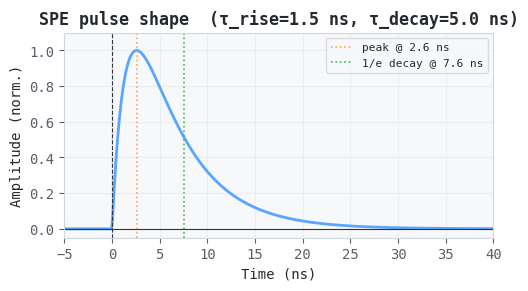

In [13]:
# ── Helper functions ─────────────────────────────────────────────────────────

# Interpolated QE function (clamps to 0 outside the defined range)
_qe_interp = interp1d(
    QE_CURVE_NM, QE_CURVE_FRAC,
    kind='linear', bounds_error=False, fill_value=0.0,
)

def photon_energy_MeV_to_wavelength_nm(energy_MeV):
    energy_J = energy_MeV * 1e6 * e_charge   # MeV → eV → J
    wavelength_m = (h * c) / energy_J
    return wavelength_m * 1e9

def apply_qe(wavelengths_nm, rng=None):
    """
    Stochastic QE filter.
    Returns boolean mask: True where a photoelectron is emitted.
    """
    if rng is None:
        rng = np.random.default_rng()
    qe = _qe_interp(wavelengths_nm)
    return rng.random(len(wavelengths_nm)) < qe

def spe_pulse(t_ns):
    """
    Single-photoelectron current pulse shape (arbitrary units, peak ≈ 1).
    I(t) = A*(exp(-t/tau_d) - exp(-t/tau_r))  for t >= 0, else 0.
    Normalised so the peak value is 1.
    """
    t = np.asarray(t_ns, dtype=float)
    pulse = np.where(
        t >= 0,
        np.exp(-t / SPE_TAU_DECAY_NS) - np.exp(-t / SPE_TAU_RISE_NS),
        0.0,
    )
    peak = pulse.max()
    return pulse / peak if peak > 0 else pulse

def build_waveform(pe_times_ns, t_bins):
    """
    Convolve a list of photoelectron arrival times with the SPE pulse shape
    to produce the total PMT anode current waveform.

    pe_times_ns : array of photoelectron arrival times [ns]
    t_bins      : 1-D array of time bin centres [ns]
    Returns     : current waveform in units of (electrons / ns) * PMT_GAIN
    """
    dt = t_bins[1] - t_bins[0]
    waveform = np.zeros(len(t_bins))
    spe_t    = t_bins - t_bins[0]           # pulse kernel starting at 0
    spe_k    = spe_pulse(spe_t)             # shape kernel

    for t_pe in pe_times_ns:
        idx = np.searchsorted(t_bins, t_pe)
        if 0 <= idx < len(t_bins):
            # Shift the SPE kernel to start at idx
            end = min(idx + len(spe_k), len(waveform))
            seg_len = end - idx
            waveform[idx:end] += spe_k[:seg_len]

    # Scale to physical current: PMT_GAIN electrons per pe, dt converts to charge
    return waveform * PMT_GAIN

# Pre-build the time axis once
T_BINS = np.arange(T_START_NS, T_END_NS, T_BIN_NS)

print('Helper functions defined.')
print(f'  Waveform window: {T_START_NS} → {T_END_NS} ns  ({len(T_BINS)} bins @ {T_BIN_NS} ns)')

# ── SPE pulse shape inset ─────────────────────────────────────────────────────
t_inset = np.linspace(-5, 40, 500)

fig_spe, ax_spe = plt.subplots(figsize=(5, 2.8), constrained_layout=True)
ax_spe.plot(t_inset, spe_pulse(t_inset), color='#58a6ff', linewidth=2)
ax_spe.axhline(0, color='#30363d', linewidth=0.8)
ax_spe.axvline(0, color='#30363d', linewidth=0.8, linestyle='--')

# Mark rise and decay time constants
t_peak = SPE_TAU_RISE_NS * SPE_TAU_DECAY_NS / (SPE_TAU_DECAY_NS - SPE_TAU_RISE_NS) \
         * np.log(SPE_TAU_DECAY_NS / SPE_TAU_RISE_NS)
ax_spe.axvline(t_peak,                   color='#ffa657', linestyle=':', linewidth=1.2,
               label=f'peak @ {t_peak:.1f} ns')
ax_spe.axvline(t_peak + SPE_TAU_DECAY_NS, color='#3fb950', linestyle=':', linewidth=1.2,
               label=f'1/e decay @ {t_peak + SPE_TAU_DECAY_NS:.1f} ns')

ax_spe.set_xlabel('Time (ns)')
ax_spe.set_ylabel('Amplitude (norm.)')
ax_spe.set_title(
    f'SPE pulse shape  (τ_rise={SPE_TAU_RISE_NS} ns, τ_decay={SPE_TAU_DECAY_NS} ns)',
    fontweight='bold',
)
ax_spe.legend(fontsize=8)
ax_spe.set_xlim(-5, 40)
ax_spe.set_ylim(-0.05, 1.1)
plt.show()

In [14]:
# ── Load a ROOT file and compute the PMT response ───────────────────────────
rng = np.random.default_rng(seed=42)   # fixed seed for reproducibility

with uproot.open(FILE_PATH) as f:
    hits       = f["PhotonHits"]
    energies   = hits["energy"].array(library="np")        # eV
    arr_times  = hits["arrival_time"].array(library="np")  # ns (local time)
    ev_ids     = hits["EvID"].array(library="np")

# Convert photon energy → wavelength → QE filter
wavelengths = photon_energy_MeV_to_wavelength_nm(energies)
pe_mask     = apply_qe(wavelengths, rng=rng)

print(f'Total photons hitting cathode : {len(energies):>8,}')
print(f'After QE filter (photoelectrons): {pe_mask.sum():>6,}  '
      f'(mean QE eff = {pe_mask.mean()*100:.1f}%)')

# Per-event photoelectron times
pe_times_by_event = {}
for ev, t, keep in zip(ev_ids, arr_times, pe_mask):
    if keep:
        pe_times_by_event.setdefault(int(ev), []).append(float(t))

# Build waveform for each event; also collect average waveform
all_waveforms   = []
n_pe_per_event  = []

for ev in sorted(pe_times_by_event):
    pe_times = np.array(pe_times_by_event[ev])
    # Align trigger: set t=0 to the first photoelectron arrival in this event
    pe_times = pe_times - pe_times.min()
    wf = build_waveform(pe_times, T_BINS)
    all_waveforms.append(wf)
    n_pe_per_event.append(len(pe_times))

all_waveforms  = np.array(all_waveforms)  # shape (n_events, n_bins)
n_pe_per_event = np.array(n_pe_per_event)
mean_waveform  = all_waveforms.mean(axis=0)

print(f'Events with ≥1 photoelectron  : {len(all_waveforms):>8,}')
print(f'Mean photoelectrons / event   : {n_pe_per_event.mean():>8.1f}')


Total photons hitting cathode : 1,356,776
After QE filter (photoelectrons): 290,766  (mean QE eff = 21.4%)
Events with ≥1 photoelectron  :    1,000
Mean photoelectrons / event   :    290.8


Saved: pmt_response.png


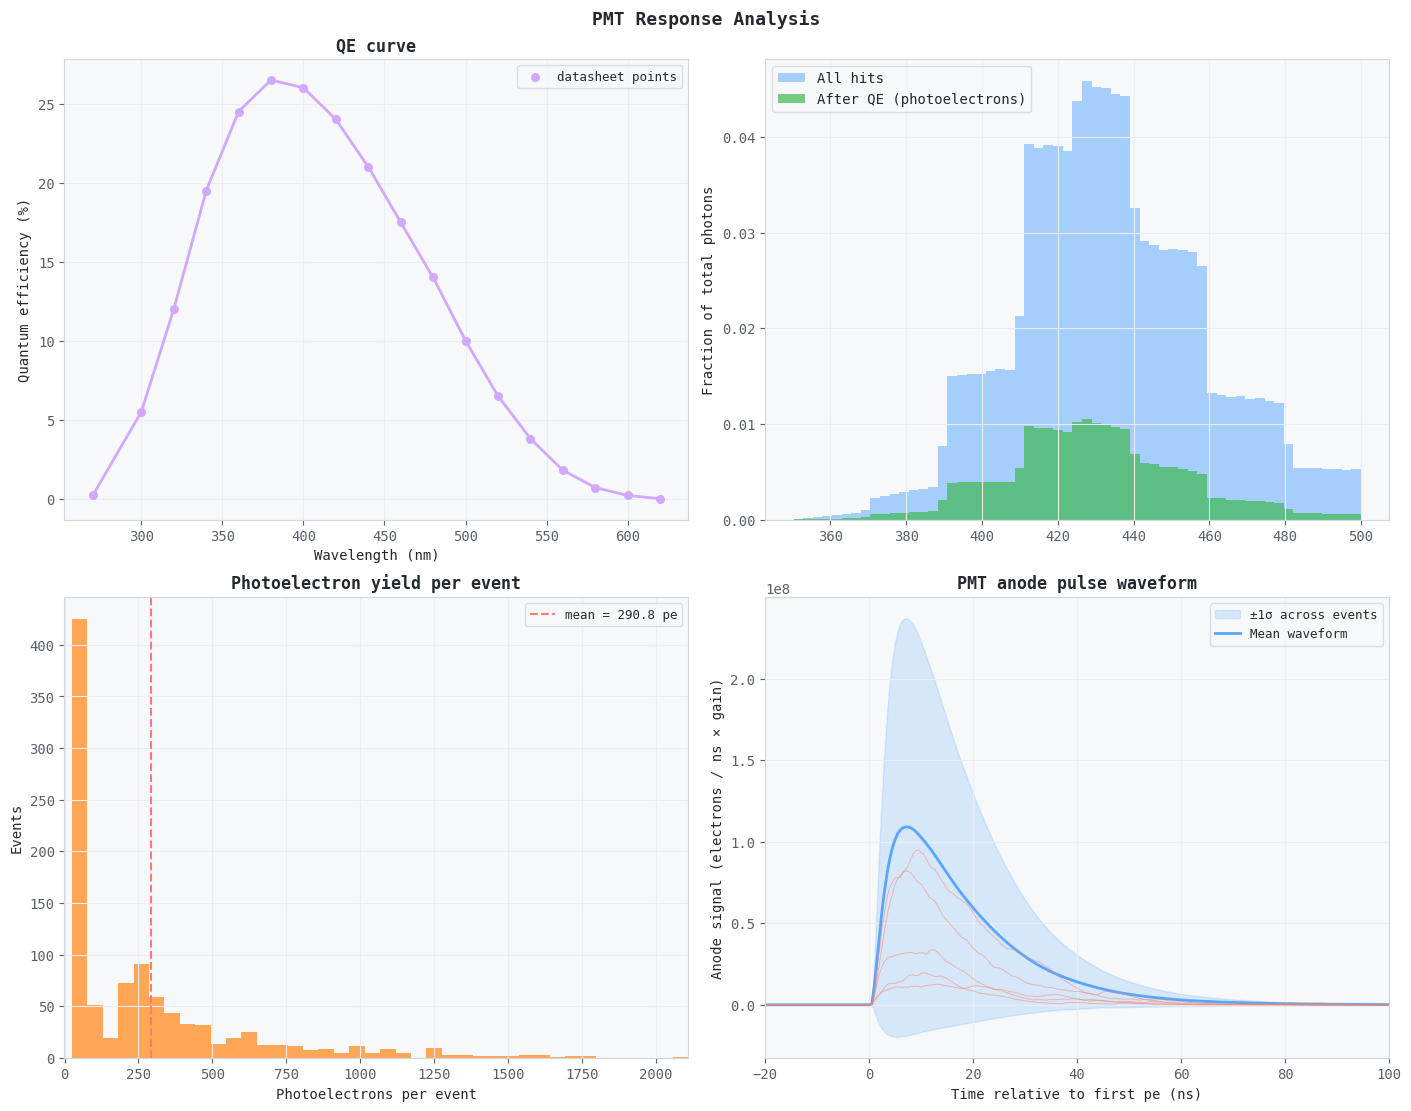

Saved: pmt_charge_spectrum.png


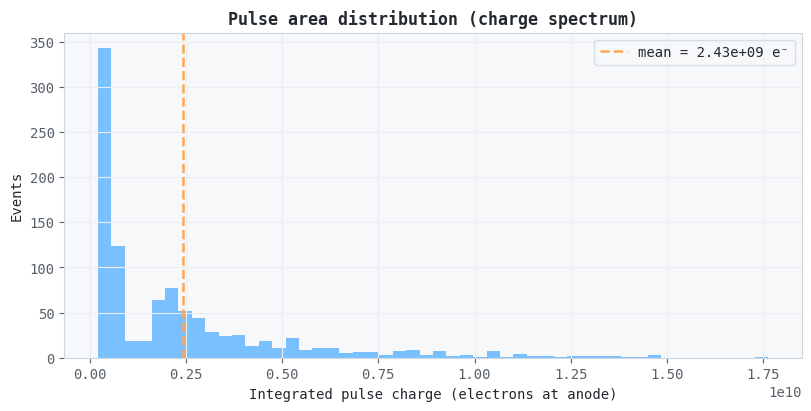


── Summary ─────────────────────────────────────────────────
  Events analysed         :    1,000
  Mean pe / event         :    290.8
  Std pe / event          :    339.1
  Mean integrated charge  : 2.43e+09  electrons
  Std integrated charge   : 2.83e+09  electrons
  Charge resolution (σ/μ) :   116.6%


In [15]:
# ── Plots ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 11), constrained_layout=True)
fig.suptitle('PMT Response Analysis', fontsize=13, fontweight='bold')
gs  = gridspec.GridSpec(2, 2, figure=fig)

# ── 1. QE curve ──────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
wl_plot = np.linspace(QE_CURVE_NM[0], QE_CURVE_NM[-1], 400)
ax1.plot(wl_plot, _qe_interp(wl_plot) * 100,
         color='#d2a8ff', linewidth=2)
ax1.scatter(QE_CURVE_NM, QE_CURVE_FRAC * 100,
            color='#d2a8ff', s=30, zorder=5, label='datasheet points')
ax1.set_xlabel('Wavelength (nm)')
ax1.set_ylabel('Quantum efficiency (%)')
ax1.set_title('QE curve', fontweight='bold')
ax1.legend(fontsize=9)

# ── 2. Detected photon wavelength spectrum (before & after QE) ───────────────
ax2 = fig.add_subplot(gs[0, 1])
bins = np.linspace(wavelengths.min(), wavelengths.max(), 60)
total = len(wavelengths)
ax2.hist(wavelengths,          bins=bins, color='#58a6ff', alpha=0.5,
         weights=np.full(len(wavelengths),          1/total),
         label='All hits')
ax2.hist(wavelengths[pe_mask], bins=bins, color='#3fb950', alpha=0.7,
         weights=np.full(len(wavelengths[pe_mask]), 1/total),
         label='After QE (photoelectrons)')
ax2.set_ylabel('Fraction of total photons')
ax2.legend()

# ── 3. Photoelectrons per event distribution ──────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
allowed = n_pe_per_event <= np.percentile(n_pe_per_event, 99.9)
ax3.hist(n_pe_per_event[allowed], bins=40, color='#ffa657', edgecolor='none')
ax3.axvline(n_pe_per_event.mean(), color='#ff7b72', linestyle='--',
            linewidth=1.5, label=f'mean = {n_pe_per_event.mean():.1f} pe')
ax3.set_xlabel('Photoelectrons per event')
ax3.set_xlim(-0.5, np.percentile(n_pe_per_event, 99.9))  # focus on bulk of distribution
ax3.set_ylabel('Events')
ax3.set_title('Photoelectron yield per event', fontweight='bold')
ax3.legend(fontsize=9)

# ── 4. Mean PMT pulse waveform ± std ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
std_waveform = all_waveforms.std(axis=0)
ax4.fill_between(T_BINS,
                 mean_waveform - std_waveform,
                 mean_waveform + std_waveform,
                 color='#58a6ff', alpha=0.2, label='±1σ across events')
ax4.plot(T_BINS, mean_waveform, color='#58a6ff', linewidth=2,
         label='Mean waveform')
# Overplot a few individual events (first 5 with ≥5 pe) for context
plotted = 0
for wf, npe in zip(all_waveforms, n_pe_per_event):
    if npe >= 5:
        ax4.plot(T_BINS, wf, color='#f78166', linewidth=0.7, alpha=0.5)
        plotted += 1
    if plotted >= 5:
        break
ax4.set_xlabel('Time relative to first pe (ns)')
ax4.set_ylabel(f'Anode signal (electrons / ns × gain)')
ax4.set_title('PMT anode pulse waveform', fontweight='bold')
ax4.set_xlim(T_START_NS, min(T_END_NS, 100))
ax4.legend(fontsize=9)

plt.savefig('pmt_response.png', dpi=150, bbox_inches='tight')
print('Saved: pmt_response.png')
plt.show()

# ── Integrated charge per event (the PMT 'pulse area') ──────────────────────
# Q = ∫ I(t) dt  ≈  sum(waveform) * dt
# Units: electrons (with gain already folded in, so physical electrons at anode)

charges = all_waveforms.sum(axis=1) * T_BIN_NS   # electrons per event

fig2, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
allowed = charges <= np.percentile(charges, 99.9)
ax.hist(charges[allowed], bins=50, color='#79c0ff', edgecolor='none')
ax.axvline(charges.mean(), color='#ffa657', linestyle='--', linewidth=1.8,
           label=f'mean = {charges.mean():.2e} e⁻')
ax.set_xlabel('Integrated pulse charge (electrons at anode)')
ax.set_ylabel('Events')
ax.set_title('Pulse area distribution (charge spectrum)', fontweight='bold')
ax.legend(fontsize=10)

plt.savefig('pmt_charge_spectrum.png', dpi=150, bbox_inches='tight',
            facecolor=fig2.get_facecolor())
print('Saved: pmt_charge_spectrum.png')
plt.show()

print()
print('── Summary ─────────────────────────────────────────────────')
print(f'  Events analysed         : {len(charges):>8,}')
print(f'  Mean pe / event         : {n_pe_per_event.mean():>8.1f}')
print(f'  Std pe / event          : {n_pe_per_event.std():>8.1f}')
print(f'  Mean integrated charge  : {charges.mean():>8.2e}  electrons')
print(f'  Std integrated charge   : {charges.std():>8.2e}  electrons')
print(f'  Charge resolution (σ/μ) : {charges.std()/charges.mean()*100:>7.1f}%')


RC time constant τ = 1.00 ns  (R=50 Ω, C=20 pF)
Saved: pmt_voltage.png


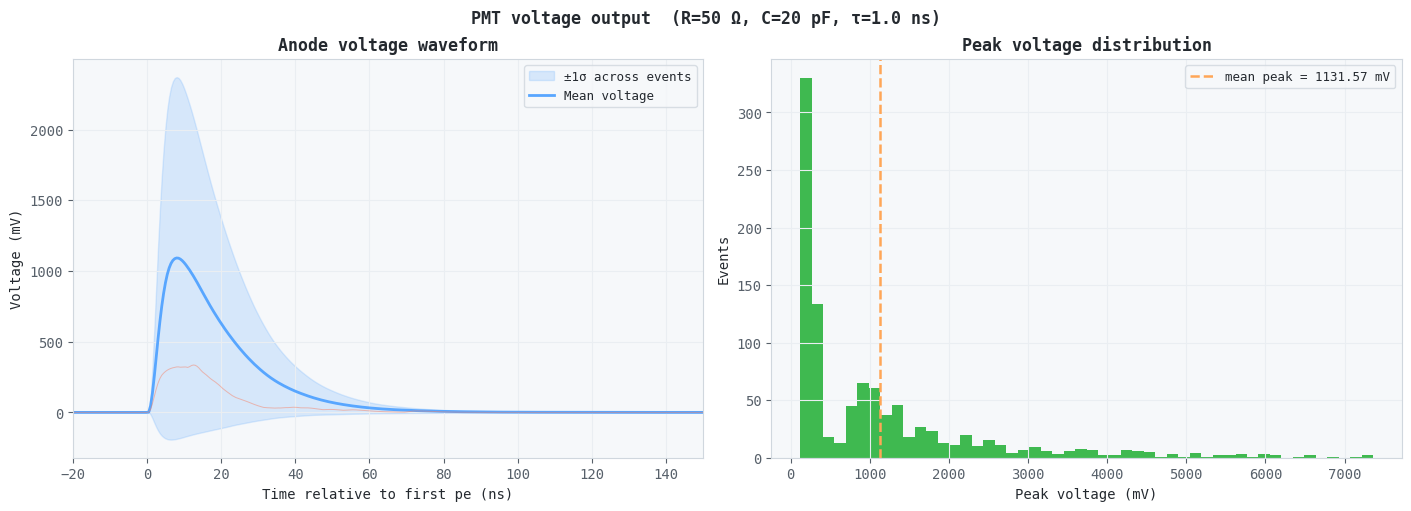


Mean peak voltage : 1131.571 mV
Std peak voltage  : 1315.135 mV
Voltage resolution: 116.2%


In [16]:
from scipy.signal import fftconvolve

# ── Circuit parameters ─────────────────────────────────────────────────────
# ★ Edit these to match your readout circuit ★
R_LOAD_OHM  = 50.0          # load resistance  [Ω]  — 50 Ω = standard coax
C_STRAY_F   = 20e-12        # stray capacitance [F]  — 20 pF typical
# ──────────────────────────────────────────────────────────────────────────

TAU_RC_NS = (R_LOAD_OHM * C_STRAY_F) * 1e9   # RC time constant in ns

def current_to_voltage(waveform_electrons_per_ns, t_bins):
    """
    Convert anode current waveform to voltage across R_load.

    The anode current I(t) [electrons/ns] is first converted to SI [Amperes],
    then convolved with the RC circuit impulse response h(t) = (1/τ)*exp(-t/τ).
    V(t) = (I * h) * dt   gives volts across R_load.

    Parameters
    ----------
    waveform_electrons_per_ns : array
        Output of build_waveform — already scaled by PMT_GAIN.
    t_bins : array
        Time axis in ns (uniform spacing).

    Returns
    -------
    voltage : array  [Volts]
    """
    dt_ns  = t_bins[1] - t_bins[0]
    dt_s   = dt_ns * 1e-9

    # Convert electrons/ns → Amperes
    # (electrons/ns) * (e_charge C/electron) / (1e-9 s/ns) = A
    I_amp = waveform_electrons_per_ns * e_charge / 1e-9

    # RC impulse response kernel (same time grid, causal)
    t_kernel = np.arange(0, 5 * TAU_RC_NS, dt_ns)   # 5τ is enough to decay
    if TAU_RC_NS > 0:
        h = (1.0 / (TAU_RC_NS * 1e-9)) * np.exp(-t_kernel / TAU_RC_NS)
    else:
        # Ideal resistive load (τ → 0): voltage = I * R directly
        h = np.array([1.0 / dt_s])

    # Convolve and scale by dt to keep units correct
    V_conv = fftconvolve(I_amp, h * dt_s, mode='full')[:len(t_bins)]

    # Voltage across R_load: V = I_convolved * R
    return V_conv * R_LOAD_OHM


# ── Compute per-event voltage waveforms ────────────────────────────────────────
print(f'RC time constant τ = {TAU_RC_NS:.2f} ns  '
      f'(R={R_LOAD_OHM:.0f} Ω, C={C_STRAY_F*1e12:.0f} pF)')

voltage_waveforms = np.array([
    current_to_voltage(wf, T_BINS) for wf in all_waveforms
])
mean_voltage = voltage_waveforms.mean(axis=0)
std_voltage  = voltage_waveforms.std(axis=0)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
fig.suptitle(
    f'PMT voltage output  (R={R_LOAD_OHM:.0f} Ω, '
    f'C={C_STRAY_F*1e12:.0f} pF, τ={TAU_RC_NS:.1f} ns)',
    fontsize=12, fontweight='bold',
)

# Panel 1: mean voltage waveform ± std
ax = axes[0]
ax.fill_between(T_BINS,
                (mean_voltage - std_voltage) * 1e3,
                (mean_voltage + std_voltage) * 1e3,
                color='#58a6ff', alpha=0.2, label='±1σ across events')
ax.plot(T_BINS, mean_voltage * 1e3, color='#58a6ff',
        linewidth=2, label='Mean voltage')
for wf_v, npe in zip(voltage_waveforms, n_pe_per_event):
    if npe >= 5:
        ax.plot(T_BINS, wf_v * 1e3, color='#f78166',
                linewidth=0.7, alpha=0.5)
        break   # just one example trace for context
ax.set_xlabel('Time relative to first pe (ns)')
ax.set_ylabel('Voltage (mV)')
ax.set_title('Anode voltage waveform', fontweight='bold')
ax.set_xlim(T_START_NS, min(T_END_NS, 150))
ax.legend(fontsize=9)

# Panel 2: peak voltage distribution
peak_voltages = voltage_waveforms.max(axis=1) * 1e3   # PMT pulses are negative
ax2 = axes[1]
allowed = peak_voltages <= np.percentile(peak_voltages, 99.9)
ax2.hist(peak_voltages[allowed], bins=50, color='#3fb950', edgecolor='none')
ax2.axvline(peak_voltages.mean(), color='#ffa657', linestyle='--',
            linewidth=1.8,
            label=f'mean peak = {peak_voltages.mean():.2f} mV')
ax2.set_xlabel('Peak voltage (mV)')
ax2.set_ylabel('Events')
ax2.set_title('Peak voltage distribution', fontweight='bold')
ax2.legend(fontsize=9)

plt.savefig('pmt_voltage.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
print('Saved: pmt_voltage.png')
plt.show()

print(f'\nMean peak voltage : {peak_voltages.mean():.3f} mV')
print(f'Std peak voltage  : {peak_voltages.std():.3f} mV')
print(f'Voltage resolution: {peak_voltages.std()/abs(peak_voltages.mean())*100:.1f}%')

Saved: pmt_discriminator.png
Trigger efficiency: 127/1000 events = 12.7%


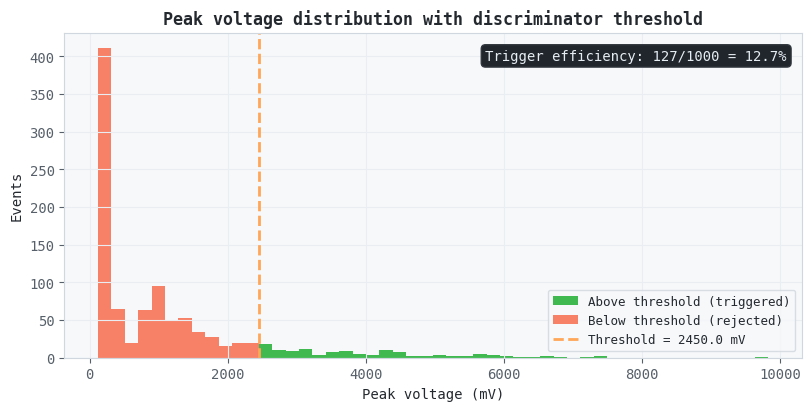

In [17]:
DISCRIMINATOR_THRESHOLD_MV = 2450.0   # ★ set to your actual threshold

fig2, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)

counts, bin_edges = np.histogram(peak_voltages, bins=50)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
width = bin_edges[1] - bin_edges[0]

colors = np.where(bin_centers < DISCRIMINATOR_THRESHOLD_MV, '#f78166', '#3fb950')

ax.bar(bin_centers, counts, width=width, color=colors, edgecolor='none')

ax.axvline(DISCRIMINATOR_THRESHOLD_MV, color='#ffa657',
           linestyle='--', linewidth=2)

# Dummy handles for the legend
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
ax.legend(handles=[
    Patch(facecolor='#3fb950', label='Above threshold (triggered)'),
    Patch(facecolor='#f78166', label='Below threshold (rejected)'),
    Line2D([0], [0], color='#ffa657', linestyle='--', linewidth=2,
           label=f'Threshold = {DISCRIMINATOR_THRESHOLD_MV:.1f} mV'),
], fontsize=9)


n_above = (peak_voltages >= DISCRIMINATOR_THRESHOLD_MV).sum()
n_total = len(peak_voltages)
efficiency = 100 * n_above / n_total

ax.set_xlabel('Peak voltage (mV)')
ax.set_ylabel('Events')
ax.set_title('Peak voltage distribution with discriminator threshold',
             fontweight='bold')

ax.text(0.98, 0.95,
        f'Trigger efficiency: {n_above}/{n_total} = {efficiency:.1f}%',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=10, color='#e6edf3',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#21262d',
                  edgecolor='#30363d'))

plt.savefig('pmt_discriminator.png', dpi=150, bbox_inches='tight',
            facecolor=fig2.get_facecolor())
print(f'Saved: pmt_discriminator.png')
print(f'Trigger efficiency: {n_above}/{n_total} events = {efficiency:.1f}%')
plt.show()

In [28]:
# ═══════════════════════════════════════════════════════════════════════════
# ENERGY SWEEP — imports, config, helpers
# ═══════════════════════════════════════════════════════════════════════════
import os, glob, re
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
particle = "e+"
SWEEP_DIR = f"energy_sweep_{particle}_0.01MeV_to_1GeV_nevents1000"
PATTERN   = os.path.join(SWEEP_DIR, "scoring_e*MeV.root")
"""
plt.rcParams.update({
    "figure.facecolor": "#0e1117",
    "axes.facecolor":   "#161b22",
    "axes.edgecolor":   "#30363d",
    "axes.labelcolor":  "#e6edf3",
    "axes.titlecolor":  "#e6edf3",
    "axes.grid":        True,
    "grid.color":       "#21262d",
    "grid.linewidth":   0.8,
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "text.color":       "#e6edf3",
    "legend.facecolor": "#161b22",
    "legend.edgecolor": "#30363d",
    "font.family":      "monospace",
    "font.size":        10,
    "lines.linewidth":  2.0,
    "lines.markersize": 0,
})
"""

def parse_energy(path):
    """Extract energy in MeV from filename like scoring_e123p4567MeV.root"""
    m = re.match(r"scoring_e([0-9p]+)MeV\.root", os.path.basename(path))
    if not m:
        return None
    return float(m.group(1).replace('p', '.'))

def load_yield(path):
    """
    Returns (mean_produced, sem_produced, mean_hits, sem_hits, n_events).
    produced = scintillation photons created in scintillator.
    hits     = optical photons that reached the PMT cathode.
    """
    with uproot.open(path) as f:
        prod_n  = f["PhotonsProduced"]["n_produced"].array(library="np").astype(float)
        hit_ev  = f["PhotonHits"]["EvID"].array(library="np")
        prod_ev = f["PhotonsProduced"]["EvID"].array(library="np")
    n_events  = len(prod_n)
    hit_counts = np.bincount(hit_ev, minlength=n_events).astype(float)
    mean_prod = prod_n.mean()
    sem_prod  = prod_n.std(ddof=1) / np.sqrt(n_events)
    mean_hits = hit_counts.mean()
    sem_hits  = hit_counts.std(ddof=1) / np.sqrt(n_events)
    return mean_prod, sem_prod, mean_hits, sem_hits, n_events

print('Helpers loaded.')

Helpers loaded.


In [29]:
# ── Load all files ────────────────────────────────────────────────────────────
files = glob.glob(PATTERN)
print(f'Found {len(files)} file(s) in {SWEEP_DIR}/')

rows = []
for path in files:
    e = parse_energy(path)
    if e is None:
        print(f'  Could not parse: {path}')
        continue
    mp, sp, mh, sh, n = load_yield(path)
    rows.append({'energy_MeV': e,
                 'mean_produced': mp, 'sem_produced': sp,
                 'mean_hits':     mh, 'sem_hits':     sh,
                 'n_events': n})

rows.sort(key=lambda r: r['energy_MeV'])
print(f'Loaded {len(rows)} energy points.')

# Arrays for plotting
E        = np.array([r['energy_MeV']   for r in rows])
produced = np.array([r['mean_produced'] for r in rows])
prod_err = np.array([r['sem_produced']  for r in rows])
hits     = np.array([r['mean_hits']     for r in rows])
hits_err = np.array([r['sem_hits']      for r in rows])
# Detection efficiency: fraction of produced photons that reach the PMT
eff      = np.where(produced > 0, hits / produced * 100, np.nan)


Found 100 file(s) in energy_sweep_e+_0.01MeV_to_1GeV_nevents1000/
Loaded 100 energy points.


Saved: energy_sweep_e+_0.01MeV_to_1GeV_nevents1000/energy_yield_curve.png


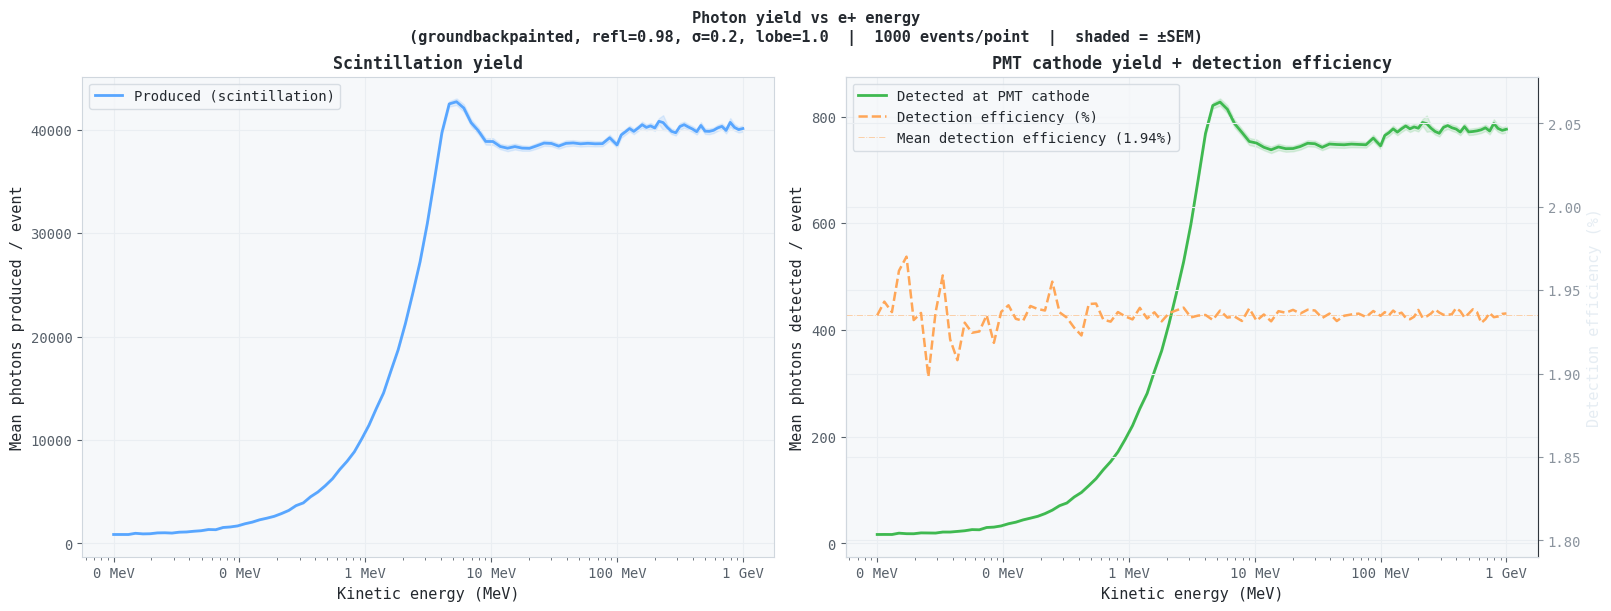

In [30]:
# ── Yield curve: two panels ───────────────────────────────────────────────────
col_prod = '#58a6ff'   # blue  — produced
col_hits = '#3fb950'   # green — detected
col_eff  = '#ffa657'   # amber — efficiency

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
fig.suptitle(
    f"Photon yield vs {particle} energy\n"
    '(groundbackpainted, refl=0.98, σ=0.2, lobe=1.0  |  '
    f'{rows[0]["n_events"]} events/point  |  shaded = ±SEM)',
    fontsize=11, fontweight='bold',
)

def style_twinx(ax):
    ax.spines['right'].set_color('#30363d')
    ax.tick_params(colors='#8b949e')
    ax.yaxis.label.set_color('#e6edf3')

def format_energy_axis(ax):
    ax.set_xscale('log')
    ax.set_xlabel('Kinetic energy (MeV)', fontsize=11)
    ax.xaxis.set_major_formatter(
        ticker.FuncFormatter(
            lambda x, _: (f'{x/1000:.0f} GeV' if x >= 1000
                          else f'{x:.0f} MeV')))

# ── Panel 1: produced photons only ───────────────────────────────────────────
ax1.fill_between(E, produced - prod_err, produced + prod_err,
                 color=col_prod, alpha=0.15)
ax1.plot(E, produced, color=col_prod, linewidth=2,
         label='Produced (scintillation)')
ax1.set_ylabel('Mean photons produced / event', fontsize=11)
ax1.legend(loc='upper left', fontsize=10)
ax1.set_title('Scintillation yield', fontweight='bold')
format_energy_axis(ax1)

# ── Panel 2: detected photons + efficiency ────────────────────────────────────
ax2_eff = ax2.twinx()
style_twinx(ax2_eff)

ax2.fill_between(E, hits - hits_err, hits + hits_err,
                 color=col_hits, alpha=0.15)
ax2.plot(E, hits, color=col_hits, linewidth=2,
         label='Detected at PMT cathode')
ax2.set_ylabel('Mean photons detected / event', fontsize=11)
format_energy_axis(ax2)
ax2.set_title('PMT cathode yield + detection efficiency', fontweight='bold')

ax2_eff.plot(E, eff, color=col_eff, linewidth=1.8, linestyle='--',
             label='Detection efficiency (%)')
ax2_eff.axhline(np.mean(eff), color=col_eff, linestyle='-.', linewidth=0.7, alpha=0.5,
                          label=f'Mean detection efficiency ({np.mean(eff):.2f}%)')
ax2_eff.set_ylabel('Detection efficiency (%)', fontsize=11)

# Tight scale: pad 150% above and below the actual data range
eff_valid = eff[np.isfinite(eff)]
eff_margin = (eff_valid.max() - eff_valid.min()) * 1.50
ax2_eff.set_ylim(eff_valid.min() - eff_margin,
                 eff_valid.max() + eff_margin)

lines3, labels3 = ax2.get_legend_handles_labels()
lines4, labels4 = ax2_eff.get_legend_handles_labels()
ax2.legend(lines3 + lines4, labels3 + labels4, loc='upper left', fontsize=10)

OUTPUT_PNG = os.path.join(SWEEP_DIR, 'energy_yield_curve.png')
plt.savefig(OUTPUT_PNG, dpi=150, bbox_inches='tight')
print(f'Saved: {OUTPUT_PNG}')
plt.show()

In [34]:
# ═══════════════════════════════════════════════════════════════════════════
# STOPPING ANALYSIS
# For each energy point, estimate whether the particle is stopped or
# through-going, and compute the critical angle above which it stops.
#
# Key relation:
#   deposited_energy [MeV] = mean_produced / SCINT_YIELD
#   stopping fraction      = deposited_energy / E_kinetic
#     → 1.0  means all energy deposited (stopped)
#     → small means MIP-like (through-going)
#
# Critical angle:
#   at θ > θ_crit the particle stops because the longer path length
#   (×1/cosθ) exceeds the particle's range.
#   cos(θ_crit) = deposited_fraction  (clamped to [0,1])
#   θ_crit = 90° when particle is already stopped at θ=0°
# ═══════════════════════════════════════════════════════════════════════════

# ★ Adjust these to your simulation settings ★
SCINT_YIELD      = 10000.0   # photons per MeV deposited
SCINT_THICKNESS  = 20.0      # mm — full thickness (2 × halfX = 2 × 10 mm)

# Fraction of kinetic energy deposited at θ=0°
# If this is ≥ STOP_FRACTION_THRESHOLD the particle is considered stopped
STOP_FRACTION_THRESHOLD = 0.98   # ★ tune: 0.98 = 98% of energy deposited

dep_energy   = produced / SCINT_YIELD          # MeV deposited at θ=0°
stop_frac    = dep_energy / E                  # fraction of KE deposited
stop_frac    = np.clip(stop_frac, 0.0, 1.0)

# Critical angle: cos(θ_crit) = stop_frac
# where stop_frac < 1 means through-going and θ_crit < 90°
# where stop_frac ≥ 1 means already stopped → θ_crit = 0° (constant for all θ)
theta_crit_rad = np.arccos(np.clip(stop_frac, 0.0, 1.0))
theta_crit_deg = np.degrees(theta_crit_rad)

is_stopped = stop_frac >= STOP_FRACTION_THRESHOLD

# ── Print summary ─────────────────────────────────────────────────────────────
print(f'Scintillation yield : {SCINT_YIELD:.0f} photons/MeV')
print(f'Scintillator thickness: {SCINT_THICKNESS} mm')
print(f'Stop threshold      : {STOP_FRACTION_THRESHOLD*100:.0f}% of KE deposited')
print()
print(f'{"E (MeV)":>12}  {"dep E (MeV)":>12}  {"stop frac":>10}  '
      f'{"θ_crit (°)":>11}  {"regime":>12}')
print('-' * 68)
for i, (e, sf, tc, stop) in enumerate(zip(E, stop_frac, theta_crit_deg, is_stopped)):
    regime = 'STOPPED' if stop else 'through-going'
    print(f'{e:>12.2f}  {dep_energy[i]:>12.1f}  {sf:>10.3f}  '
          f'{tc:>11.1f}  {regime:>12}')

n_stopped    = is_stopped.sum()
n_throughgoing = (~is_stopped).sum()
print()
print(f'Stopped     : {n_stopped} / {len(E)} energy points')
print(f'Through-going: {n_throughgoing} / {len(E)} energy points')


Scintillation yield : 10000 photons/MeV
Scintillator thickness: 20.0 mm
Stop threshold      : 98% of KE deposited

     E (MeV)   dep E (MeV)   stop frac   θ_crit (°)        regime
--------------------------------------------------------------------
        0.01           0.1       1.000          0.0       STOPPED
        0.01           0.1       1.000          0.0       STOPPED
        0.01           0.1       1.000          0.0       STOPPED
        0.01           0.1       1.000          0.0       STOPPED
        0.02           0.1       1.000          0.0       STOPPED
        0.02           0.1       1.000          0.0       STOPPED
        0.02           0.1       1.000          0.0       STOPPED
        0.03           0.1       1.000          0.0       STOPPED
        0.03           0.1       1.000          0.0       STOPPED
        0.03           0.1       1.000          0.0       STOPPED
        0.04           0.1       1.000          0.0       STOPPED
        0.04           0

Saved: stopping_analysis.png


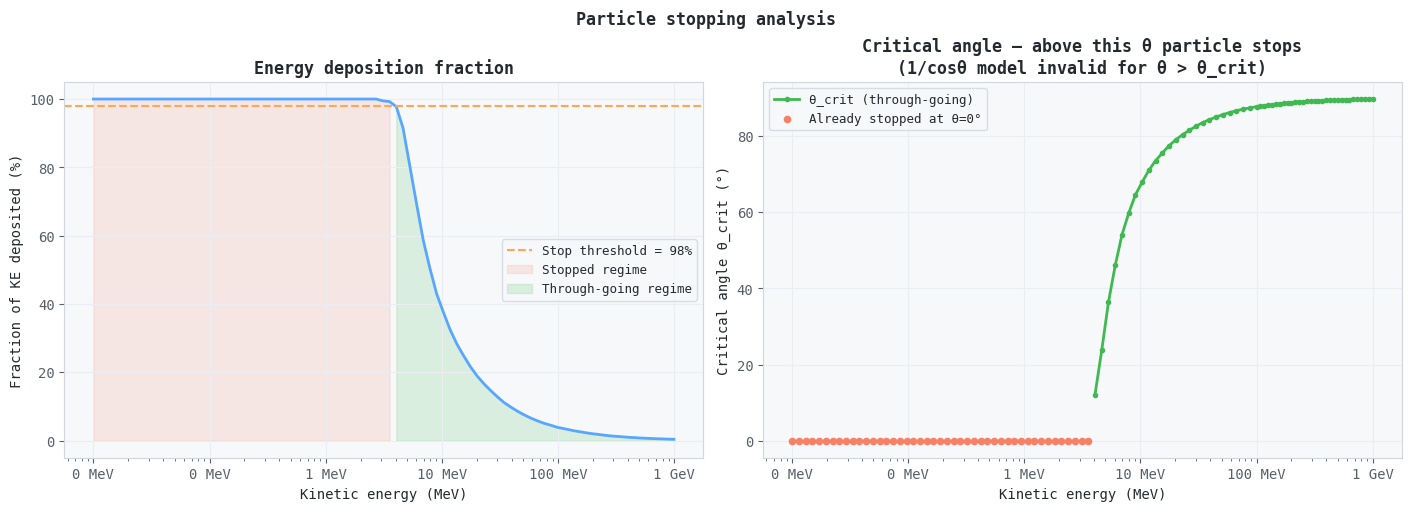

In [35]:
# ── Stopping analysis plot ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
fig.suptitle('Particle stopping analysis', fontsize=12, fontweight='bold')

# Panel 1: deposited fraction vs energy
ax = axes[0]
ax.plot(E, stop_frac * 100, color='#58a6ff', linewidth=2)
ax.axhline(STOP_FRACTION_THRESHOLD * 100, color='#ffa657',
           linestyle='--', linewidth=1.5,
           label=f'Stop threshold = {STOP_FRACTION_THRESHOLD*100:.0f}%')
ax.fill_between(E, stop_frac * 100,
                where=is_stopped, alpha=0.15, color='#f78166',
                label='Stopped regime')
ax.fill_between(E, stop_frac * 100,
                where=~is_stopped, alpha=0.15, color='#3fb950',
                label='Through-going regime')
ax.set_xscale('log')
ax.set_xlabel('Kinetic energy (MeV)')
ax.set_ylabel('Fraction of KE deposited (%)')
ax.set_title('Energy deposition fraction', fontweight='bold')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f'{x/1000:.0f} GeV' if x >= 1000 else f'{x:.0f} MeV'))
ax.legend(fontsize=9)

# Panel 2: critical angle vs energy
ax = axes[1]
ax.plot(E[~is_stopped], theta_crit_deg[~is_stopped],
        'o-', color='#3fb950', linewidth=2, markersize=3,
        label='θ_crit (through-going)')
ax.scatter(E[is_stopped], np.zeros(is_stopped.sum()),
           color='#f78166', s=20, zorder=5,
           label='Already stopped at θ=0°')
ax.set_xscale('log')
ax.set_xlabel('Kinetic energy (MeV)')
ax.set_ylabel('Critical angle θ_crit (°)')
ax.set_title('Critical angle — above this θ particle stops\n'
             '(1/cosθ model invalid for θ > θ_crit)', fontweight='bold')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f'{x/1000:.0f} GeV' if x >= 1000 else f'{x:.0f} MeV'))
ax.legend(fontsize=9)

plt.savefig(os.path.join(SWEEP_DIR, 'stopping_analysis.png'),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
print('Saved: stopping_analysis.png')
plt.show()


In [32]:
from scipy.ndimage import gaussian_filter1d

# ── Palette: multi-hue sequential (blue → teal → green → gold → coral → red) ──
PALETTE = [
    '#4e8fce',  # 80%  – muted blue
    '#3ab5b0',  # 85%  – teal
    '#5bc97a',  # 90%  – green
    '#a8c840',  # 92.5% – yellow-green
    '#f0b429',  # 95%  – amber
    '#f07b29',  # 97.5% – orange
    '#e04f5f',  # 99%  – coral-red
]

PALETTE = [
    '#e63946',  # vivid red
    '#f77f00',  # amber orange
    '#fcbf49',  # golden yellow
    '#90be6d',  # soft green
    '#2a9d8f',  # teal
    '#4cc9f0',  # cyan
    '#457b9d',  # steel blue
    '#4361ee',  # royal blue
    '#6a4c93',  # purple
    '#b5179e',  # magenta
]

SIGMA = 1.5   # ← tune this: higher = smoother, lower = more faithful to data

def peak_voltages_from_file(path, rng):
    with uproot.open(path) as f:
        hit_ev  = f['PhotonHits']['EvID'].array(library='np')
        hit_e   = f['PhotonHits']['energy'].array(library='np')
        hit_t   = f['PhotonHits']['arrival_time'].array(library='np')
        prod_ev = f['PhotonsProduced']['EvID'].array(library='np')
    n_events = len(prod_ev)
    wl   = photon_energy_MeV_to_wavelength_nm(hit_e)
    mask = apply_qe(wl, rng=rng)
    pe_by_ev = {}
    for ev, t, keep in zip(hit_ev, hit_t, mask):
        if keep:
            pe_by_ev.setdefault(int(ev), []).append(float(t))
    peak_v = []
    for ev in range(n_events):
        if ev not in pe_by_ev:
            continue
        pe_t = np.array(pe_by_ev[ev])
        pe_t = pe_t - pe_t.min()
        wf   = build_waveform(pe_t, T_BINS)
        v    = current_to_voltage(wf, T_BINS)
        peak_v.append(v.max() * 1e3)
    return np.array(peak_v)


#PERCENTILES = [80, 85, 90, 92.5, 95, 97.5, 99]
PERCENTILES = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90]
RNG_SEED    = 42

rng = np.random.default_rng(RNG_SEED)

# Sort files by energy
files_sorted = sorted(
    files,
    key=lambda p: parse_energy(p)
)

# Containers
E_plot = []
percentile_curves = {p: [] for p in PERCENTILES}

# ── Calculate peak-voltage distributions for every energy ───────────────────
for path in files_sorted:

    energy = parse_energy(path)

    # Uses your notebook function
    peak_voltages = peak_voltages_from_file(path, rng)

    # Skip invalid entries safely
    if len(peak_voltages) == 0:
        continue

    E_plot.append(energy)

    # Compute requested percentile voltages
    for p in PERCENTILES:
        vthr = np.percentile(peak_voltages, p)
        percentile_curves[p].append(vthr)

# Convert to arrays
E_plot = np.array(E_plot)

for p in PERCENTILES:
    percentile_curves[p] = np.array(percentile_curves[p])

# Match stopping mask ordering to sorted energies
sort_idx = np.argsort(E)
is_stopped_plot = is_stopped[sort_idx]

# ── Plot ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)

fig.suptitle(
    'Peak-voltage distribution evolution vs energy',
    fontsize=12, fontweight='bold'
)

all_vals = np.concatenate([percentile_curves[p] for p in PERCENTILES])
ymin, ymax = np.nanmin(all_vals), np.nanmax(all_vals)

ax.fill_between(E_plot, ymin, ymax, where=is_stopped_plot,
                color='#f78166', alpha=0.12, label='Stopped regime')
ax.fill_between(E_plot, ymin, ymax, where=~is_stopped_plot,
                color='#3fb950', alpha=0.12, label='Through-going regime')

for color, p in zip(PALETTE, PERCENTILES):
    y_smooth = gaussian_filter1d(percentile_curves[p], sigma=SIGMA)
    ax.plot(E_plot, y_smooth, '-o',
            linewidth=2, markersize=3.5,
            color=color, label=f'{p:g}%')

ax.set_xscale('log')
ax.set_xlabel('Kinetic energy (MeV)')
ax.set_ylabel('Peak voltage threshold (mV)')
ax.set_title('Voltage threshold below which X% of events lie', fontweight='bold')

ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(
        lambda x, _: f'{x/1000:.0f} GeV' if x >= 1000 else f'{x:.0f} MeV'
    )
)

ax.grid(alpha=0.2)
ax.legend(fontsize=9, ncol=2)

KeyboardInterrupt: 

Saved: pmt_peak_voltage_lut.png


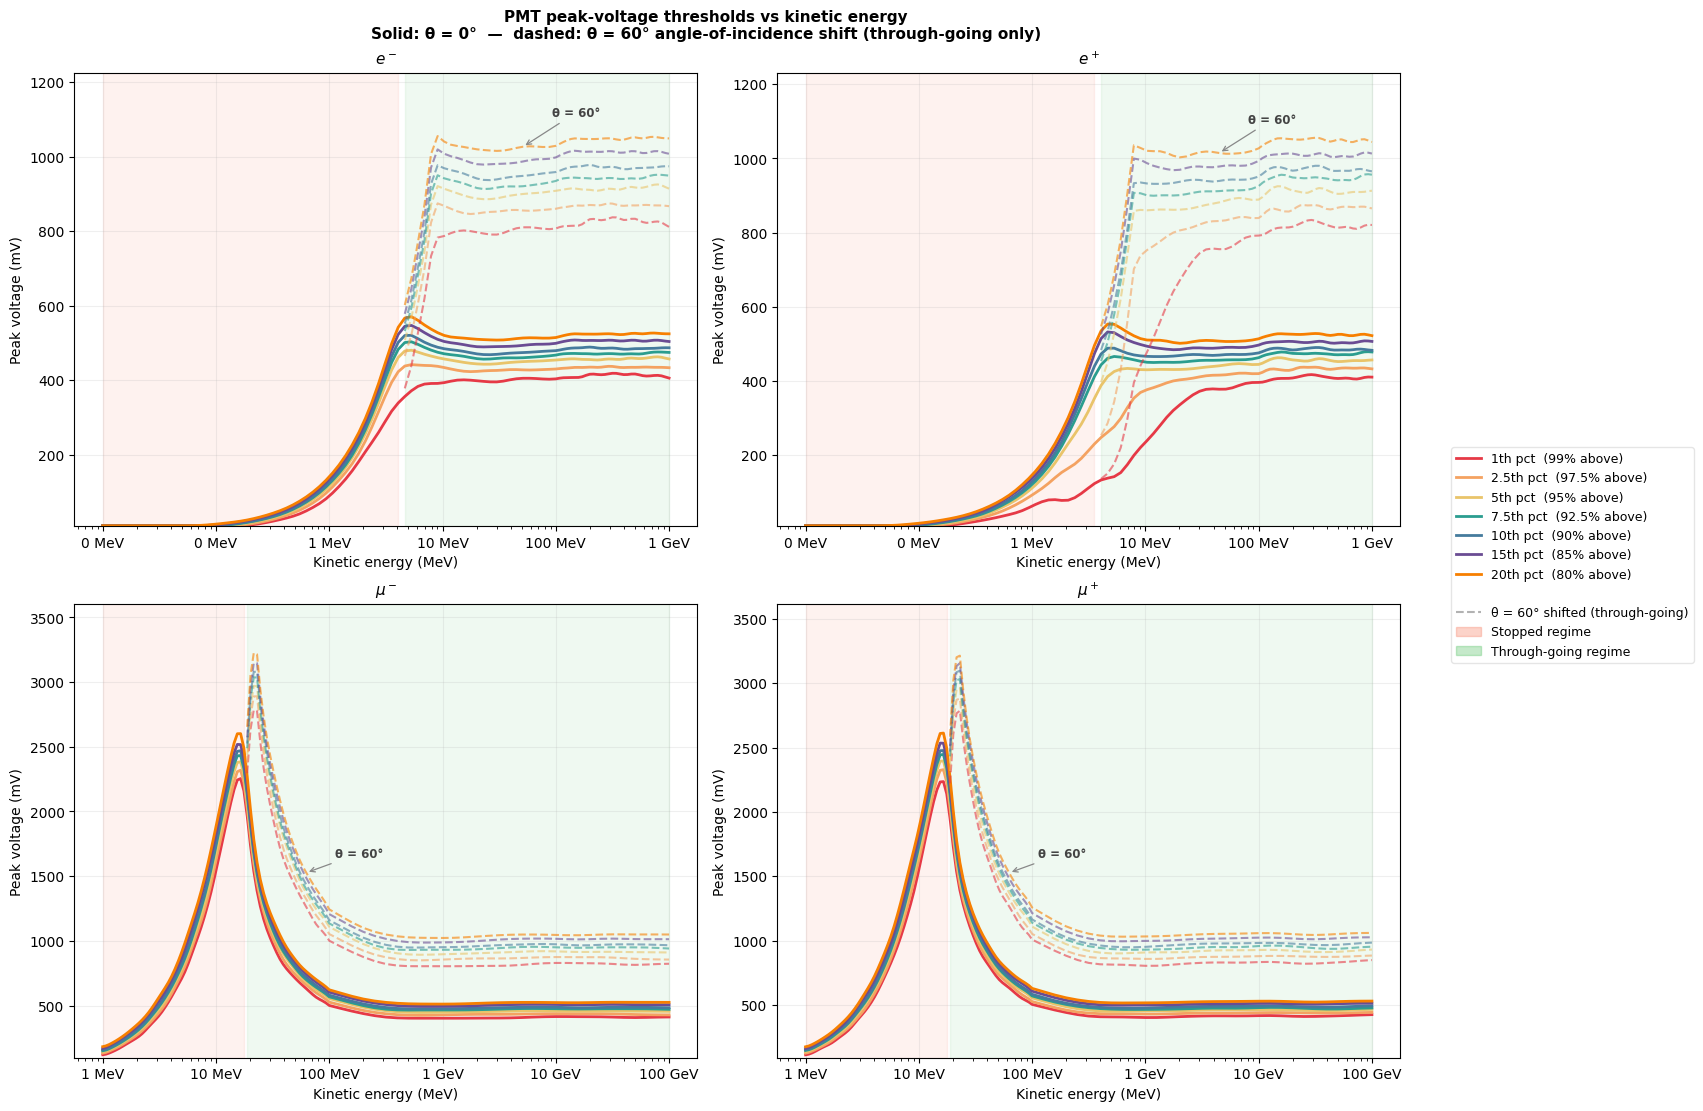

In [8]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.ndimage import gaussian_filter1d
import matplotlib.patches as mpatches

# ── Config ──────────────────────────────────────────────────────────────────
PERCENTILES  = [1, 2.5, 5, 7.5, 10, 15, 20]
SIGMA        = 1.5
THETA_ANGLE  = 60

PALETTE = [
    '#e63946',
    '#f4a261',
    '#e9c46a',
    '#2a9d8f',
    '#457b9d',
    '#6a4c93',
    '#f77f00',
]

LUT_FILES = {
    'e-':  '/home/bjorn/g4_work/g4work_project/scintilator/production/pmt_lut_e-.json',
    'e+':  '/home/bjorn/g4_work/g4work_project/scintilator/production/pmt_lut_e+.json',
    'mu-': '/home/bjorn/g4_work/g4work_project/scintilator/production/pmt_lut_mu-.json',
    'mu+': '/home/bjorn/g4_work/g4work_project/scintilator/production/pmt_lut_mu+.json',
}

# ── Angle shift model ────────────────────────────────────────────────────────
def angle_scale(theta_deg, theta_crit_deg, is_stopped):
    if is_stopped:
        return 1.0
    theta_rad      = np.radians(theta_deg)
    theta_crit_rad = np.radians(theta_crit_deg) if theta_crit_deg > 0 else np.radians(90)
    eff_rad = theta_rad if theta_deg <= theta_crit_deg else theta_crit_rad
    return 1.0 / np.cos(eff_rad)

# ── Load LUT ─────────────────────────────────────────────────────────────────
def load_lut(path):
    with open(path) as f:
        d = json.load(f)
    entries    = d['entries']
    energies   = np.array([e['energy_MeV']    for e in entries])
    is_stopped = np.array([e['is_stopped']     for e in entries])
    theta_crit = np.array([e['theta_crit_deg'] for e in entries])

    pct_curves = {p: [] for p in PERCENTILES}
    for e in entries:
        edges   = np.array(e['bin_edges_mV'])
        counts  = np.array(e['counts'])
        centres = 0.5 * (edges[:-1] + edges[1:])
        samples = np.repeat(centres, counts) if counts.sum() > 0 else np.array([0.0])
        for p in PERCENTILES:
            pct_curves[p].append(np.percentile(samples, p))

    for p in PERCENTILES:
        pct_curves[p] = np.array(pct_curves[p])

    return energies, is_stopped, theta_crit, pct_curves

# ── Plot one particle panel ──────────────────────────────────────────────────
def plot_lut(path, particle_label, ax):
    energies, is_stopped, theta_crit, pct_curves = load_lut(path)

    sort_idx   = np.argsort(energies)
    energies   = energies[sort_idx]
    is_stopped = is_stopped[sort_idx]
    theta_crit = theta_crit[sort_idx]
    for p in PERCENTILES:
        pct_curves[p] = pct_curves[p][sort_idx]

    mask_tg = ~is_stopped
    scales  = np.array([
        angle_scale(THETA_ANGLE, tc, stopped)
        for tc, stopped in zip(theta_crit, is_stopped)
    ])

    # ── Y limits: pool baseline + shifted values ──────────────────────────────
    baseline_vals = np.concatenate([pct_curves[p] for p in PERCENTILES])
    shifted_vals  = np.concatenate([
        pct_curves[p][mask_tg] * scales[mask_tg] for p in PERCENTILES
    ])
    all_vals = np.concatenate([baseline_vals, shifted_vals])
    ymin = np.nanmin(all_vals) * 0.85
    ymax = np.nanmax(all_vals) * 1.15

    # ── Regime shading ───────────────────────────────────────────────────────
    ax.fill_between(energies, ymin, ymax, where=is_stopped,
                    color='#f78166', alpha=0.10)
    ax.fill_between(energies, ymin, ymax, where=~is_stopped,
                    color='#3fb950', alpha=0.08)

    # ── Baseline percentile curves (θ = 0°) ──────────────────────────────────
    for color, p in zip(PALETTE, PERCENTILES):
        y = gaussian_filter1d(pct_curves[p], sigma=SIGMA)
        ax.plot(energies, y, '-', linewidth=2, color=color)

    # ── θ = 60° shifted curves (through-going only) ──────────────────────────
    for color, p in zip(PALETTE, PERCENTILES):
        y_base    = gaussian_filter1d(pct_curves[p], sigma=SIGMA)
        y_shifted = np.where(mask_tg, y_base * scales, np.nan)
        ax.plot(energies, y_shifted, '--', linewidth=1.5, color=color, alpha=0.6)

    # ── Direct label on the shifted band ─────────────────────────────────────
    tg_idx = np.where(mask_tg)[0]
    if len(tg_idx) > 4:
        label_i     = tg_idx[len(tg_idx) // 3]
        label_e     = energies[label_i]
        top_p       = PERCENTILES[-1]
        y_top_base  = gaussian_filter1d(pct_curves[top_p], sigma=SIGMA)
        y_top_shift = y_top_base[label_i] * scales[label_i]
        ax.annotate(
            f'θ = {THETA_ANGLE}°',
            xy=(label_e, y_top_shift),
            xytext=(label_e * 1.8, y_top_shift * 1.08),
            fontsize=8.5,
            color='#444',
            fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#888', lw=0.9),
        )

    # ── Formatting ───────────────────────────────────────────────────────────
    ax.set_xscale('log')
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel('Kinetic energy (MeV)', fontsize=10)
    ax.set_ylabel('Peak voltage (mV)', fontsize=10)
    ax.set_title(particle_label, fontweight='bold', fontsize=11)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(
        lambda x, _: f'{x/1000:.0f} GeV' if x >= 1000 else f'{x:.0f} MeV'
    ))
    ax.grid(alpha=0.20)

# ── Main figure ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11), constrained_layout=True)

fig.suptitle(
    'PMT peak-voltage thresholds vs kinetic energy\n'
    f'Solid: θ = 0°  —  dashed: θ = {THETA_ANGLE}° angle-of-incidence shift (through-going only)',
    fontsize=11, fontweight='bold'
)

particles = [
    ('e-',  r'$e^-$',   axes[0, 0]),
    ('e+',  r'$e^+$',   axes[0, 1]),
    ('mu-', r'$\mu^-$', axes[1, 0]),
    ('mu+', r'$\mu^+$', axes[1, 1]),
]

for key, label, ax in particles:
    plot_lut(LUT_FILES[key], label, ax)

# ── Shared legend ─────────────────────────────────────────────────────────────
pct_handles = []
for color, p in zip(PALETTE, PERCENTILES):
    above = 100 - p
    pct_handles.append(
        plt.Line2D([0], [0], color=color, linewidth=2,
                   label=f'{p:g}th pct  ({above:g}% above)')
    )

angle_handle = plt.Line2D(
    [0], [0], color='gray', linestyle='--', linewidth=1.5, alpha=0.6,
    label=f'θ = {THETA_ANGLE}° shifted (through-going)'
)

regime_handles = [
    mpatches.Patch(color='#f78166', alpha=0.35, label='Stopped regime'),
    mpatches.Patch(color='#3fb950', alpha=0.30, label='Through-going regime'),
]

fig.legend(
    handles=pct_handles + [plt.Line2D([], [], color='none')] + [angle_handle] + regime_handles,
    loc='center right',
    ncol=1,
    fontsize=9,
    framealpha=0.5,
    bbox_to_anchor=(1.21, 0.5),
)

outpath = 'pmt_peak_voltage_lut.png'
plt.savefig(outpath, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
print(f'Saved: {outpath}')
plt.show()

/tmp/ipykernel_45144/232181073.py:145: RuntimeWarning: invalid value encountered in divide
  return np.where(tot > 0, det / tot, np.nan).T   # transpose → (y, z)


Saved: /home/bjorn/g4_work/g4work_project/scintilator/production/energy_sweep_e+_0.01MeV_to_1GeV_nevents1000/detection_maps.png


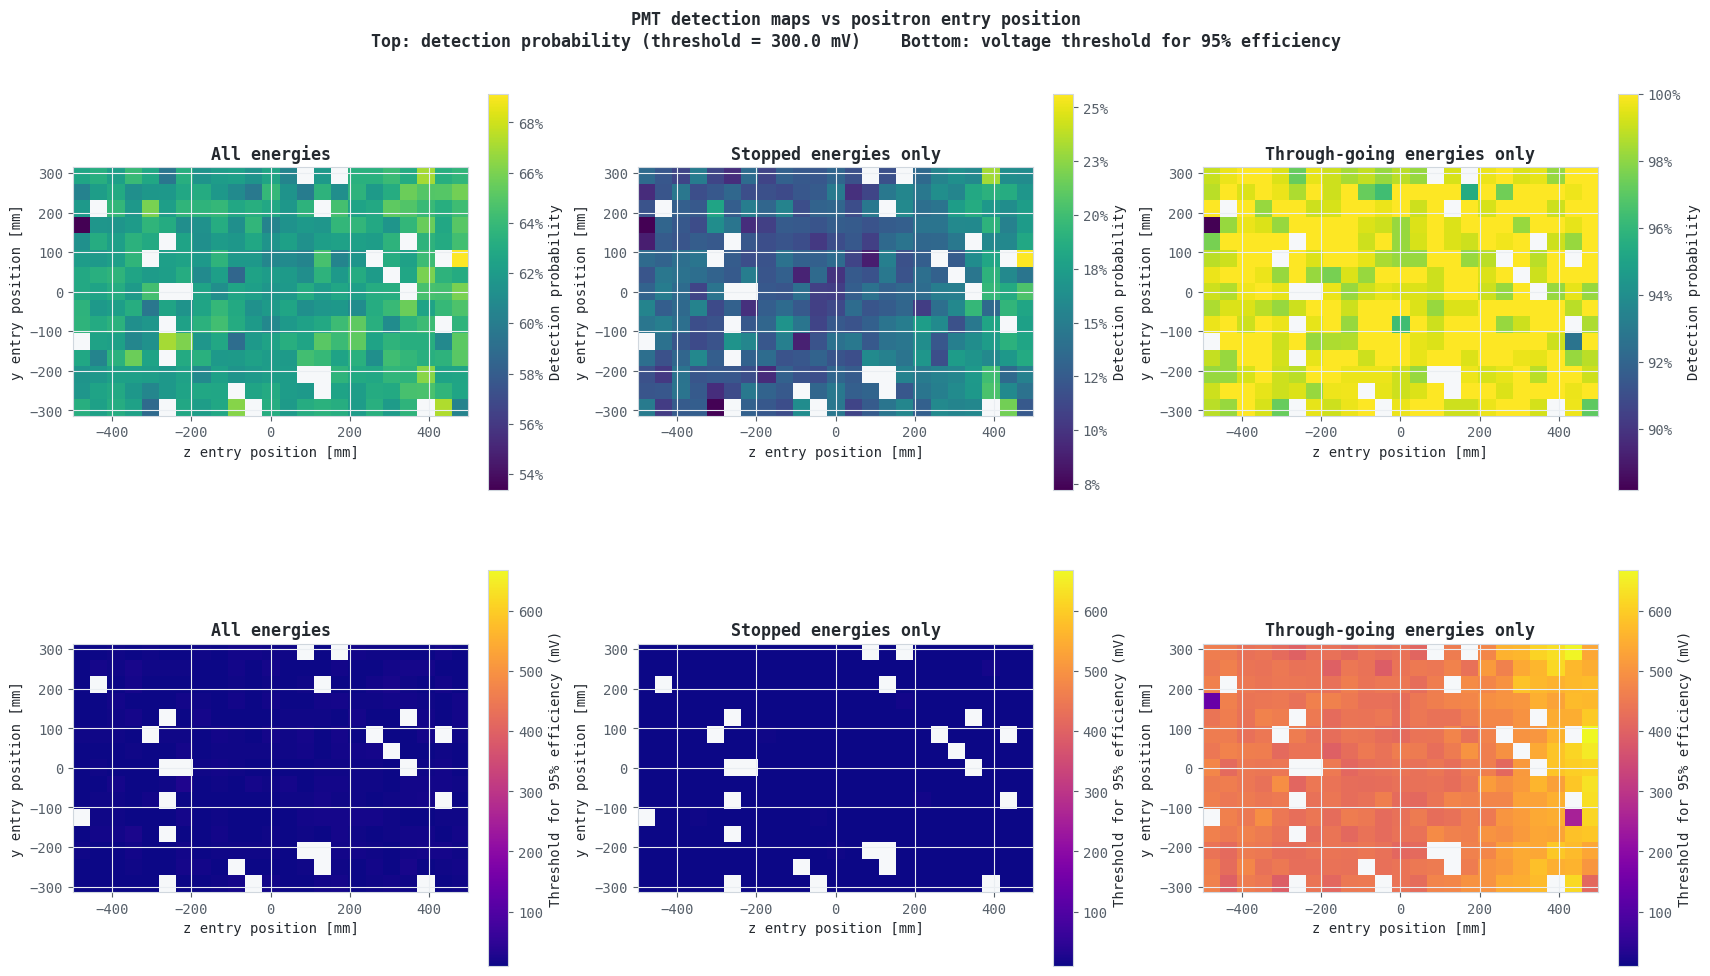

In [38]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

def peak_voltages_and_positions_from_file(path, rng):
    with uproot.open(path) as f:
        hit_ev  = f['PhotonHits']['EvID'].array(library='np')
        hit_e   = f['PhotonHits']['energy'].array(library='np')
        hit_t   = f['PhotonHits']['arrival_time'].array(library='np')
        prod_ev = f['PhotonsProduced']['EvID'].array(library='np')

        # Entry positions, indexed by EvID
        muon_ev = f['MuonEntry']['EvID'].array(library='np')
        y_arr   = f['MuonEntry']['y_entry'].array(library='np')
        z_arr   = f['MuonEntry']['z_entry'].array(library='np')

    ev_to_y = dict(zip(muon_ev, y_arr))
    ev_to_z = dict(zip(muon_ev, z_arr))

    n_events = len(prod_ev)

    wl   = photon_energy_MeV_to_wavelength_nm(hit_e)
    mask = apply_qe(wl, rng=rng)

    pe_by_ev = {}
    for ev, t, keep in zip(hit_ev, hit_t, mask):
        if keep:
            pe_by_ev.setdefault(int(ev), []).append(float(t))

    peak_v  = []
    y_out   = []
    z_out   = []

    for ev in range(n_events):
        if ev not in pe_by_ev:
            continue                          # skip zero-PE events, same as before
        pe_t = np.array(pe_by_ev[ev])
        pe_t = pe_t - pe_t.min()
        wf   = build_waveform(pe_t, T_BINS)
        v    = current_to_voltage(wf, T_BINS)
        peak_v.append(v.max() * 1e3)
        y_out.append(ev_to_y.get(ev, np.nan))
        z_out.append(ev_to_z.get(ev, np.nan))

    return np.array(peak_v), np.array(y_out), np.array(z_out)

# ── Config (add these two) ────────────────────────────────────────────────────
DETECTION_THRESHOLD_MV  = 300.0    # for the probability maps
TARGET_EFFICIENCY       = 0.95   # for the threshold map  ← tune this

N_BINS_Y = 15
Y_RANGE  = [-314, 314]
Z_RANGE  = [-500, 500]
N_BINS_Z = int(N_BINS_Y * (1000 / 628))

RNG_SEED = 42

SWEEP_DIR = "/home/bjorn/g4_work/g4work_project/scintilator/production/energy_sweep_e+_0.01MeV_to_1GeV_nevents1000"

# ── Helpers ──────────────────────────────────────────────────────────────────
rng = np.random.default_rng(RNG_SEED)
files_sorted = sorted(files, key=parse_energy)

E_sorted          = np.array([parse_energy(f) for f in files_sorted])
sort_idx          = np.argsort(E)
is_stopped_sorted = is_stopped[sort_idx]

# ── Entry-position extractor (mirrors your working notebook code) ─────────────
def load_entry_positions(path):
    """Return (y_entry, z_entry) aligned event-by-event with peak_voltages."""
    with uproot.open(path) as f:
        muon    = f["MuonEntry"]
        y_entry = muon["y_entry"].array(library="np")
        z_entry = muon["z_entry"].array(library="np")
        ev_muon = muon["EvID"].array(library="np")

        prod_ev = f["PhotonsProduced"]["EvID"].array(library="np")

    # peak_voltages_from_file only returns a value for events that had
    # at least one detected PE — we need positions for ALL events in
    # the same order as prod_ev (the loop in peak_voltages_from_file
    # iterates range(n_events) and skips events with no PEs).
    # Build a lookup: EvID → (y, z)
    ev_to_y = dict(zip(ev_muon, y_entry))
    ev_to_z = dict(zip(ev_muon, z_entry))

    n_events = len(prod_ev)
    y_out = np.array([ev_to_y.get(int(ev), np.nan) for ev in range(n_events)])
    z_out = np.array([ev_to_z.get(int(ev), np.nan) for ev in range(n_events)])

    return y_out, z_out

# ── Accumulate hits/totals per grid cell across all energies ─────────────────
def make_empty_grid():
    return np.zeros((N_BINS_Z, N_BINS_Y), dtype=float)

detected_sum_all     = make_empty_grid()
total_count_all      = make_empty_grid()

detected_sum_stopped  = make_empty_grid()
total_count_stopped   = make_empty_grid()

detected_sum_through  = make_empty_grid()
total_count_through   = make_empty_grid()

# ── Main loop ────────────────────────────────────────────────────────────────
for path, stopped_flag in zip(files_sorted, is_stopped_sorted):

    peak_voltages, y_entry, z_entry = peak_voltages_and_positions_from_file(path, rng)

    # No alignment needed — all three arrays are already in lockstep
    valid = np.isfinite(y_entry) & np.isfinite(z_entry)
    peak_voltages = peak_voltages[valid]
    y_entry       = y_entry[valid]
    z_entry       = z_entry[valid]

    detected = (peak_voltages >= DETECTION_THRESHOLD_MV).astype(float)

    # Accumulate into 2-D histograms
    det_h, _, _ = np.histogram2d(
        z_entry, y_entry,
        bins=[N_BINS_Z, N_BINS_Y],
        range=[Z_RANGE, Y_RANGE],
        weights=detected
    )
    tot_h, _, _ = np.histogram2d(
        z_entry, y_entry,
        bins=[N_BINS_Z, N_BINS_Y],
        range=[Z_RANGE, Y_RANGE],
    )

    detected_sum_all  += det_h
    total_count_all   += tot_h

    if stopped_flag:
        detected_sum_stopped += det_h
        total_count_stopped  += tot_h
    else:
        detected_sum_through += det_h
        total_count_through  += tot_h

# ── Compute probability maps ─────────────────────────────────────────────────
def prob_map(det, tot):
    return np.where(tot > 0, det / tot, np.nan).T   # transpose → (y, z)

map_all     = prob_map(detected_sum_all,     total_count_all)
map_stopped = prob_map(detected_sum_stopped, total_count_stopped)
map_through = prob_map(detected_sum_through, total_count_through)

# ── After the accumulation loop, add the threshold map computation ────────────
def threshold_for_efficiency(path, rng, target_eff):
    """
    For each grid cell, find the minimum voltage threshold that keeps
    detection efficiency >= target_eff, using all events in that cell.
    Returns a 2-D array (N_BINS_Y, N_BINS_Z) of threshold voltages in mV.
    """
    # Accumulate raw voltages per grid cell
    voltage_grid = [[[] for _ in range(N_BINS_Y)] for _ in range(N_BINS_Z)]

    z_edges = np.linspace(Z_RANGE[0], Z_RANGE[1], N_BINS_Z + 1)
    y_edges = np.linspace(Y_RANGE[0], Y_RANGE[1], N_BINS_Y + 1)

    peak_voltages, y_entry, z_entry = peak_voltages_and_positions_from_file(path, rng)
    valid = np.isfinite(y_entry) & np.isfinite(z_entry)
    peak_voltages = peak_voltages[valid]
    y_entry       = y_entry[valid]
    z_entry       = z_entry[valid]

    zi = np.searchsorted(z_edges[1:], z_entry).clip(0, N_BINS_Z - 1)
    yi = np.searchsorted(y_edges[1:], y_entry).clip(0, N_BINS_Y - 1)

    for v, zb, yb in zip(peak_voltages, zi, yi):
        voltage_grid[zb][yb].append(v)

    return voltage_grid, z_edges, y_edges


def build_threshold_map(files_sorted, is_stopped_sorted, rng, target_eff, regime=None):
    """
    regime: None = all, True = stopped only, False = through-going only
    Returns (N_BINS_Y, N_BINS_Z) threshold map in mV.
    """
    voltage_grid = [[[] for _ in range(N_BINS_Y)] for _ in range(N_BINS_Z)]

    z_edges = np.linspace(Z_RANGE[0], Z_RANGE[1], N_BINS_Z + 1)
    y_edges = np.linspace(Y_RANGE[0], Y_RANGE[1], N_BINS_Y + 1)

    for path, stopped_flag in zip(files_sorted, is_stopped_sorted):
        if regime is True  and not stopped_flag: continue
        if regime is False and     stopped_flag: continue

        peak_voltages, y_entry, z_entry = peak_voltages_and_positions_from_file(path, rng)
        valid = np.isfinite(y_entry) & np.isfinite(z_entry)
        peak_voltages = peak_voltages[valid]
        y_entry       = y_entry[valid]
        z_entry       = z_entry[valid]

        zi = np.searchsorted(z_edges[1:], z_entry).clip(0, N_BINS_Z - 1)
        yi = np.searchsorted(y_edges[1:], y_entry).clip(0, N_BINS_Y - 1)

        for v, zb, yb in zip(peak_voltages, zi, yi):
            voltage_grid[zb][yb].append(v)

    # Convert to threshold map: (1 - target_eff) percentile of voltages
    # e.g. target_eff=0.5 → voltages above the 50th percentile → threshold = median
    thr_map = np.full((N_BINS_Z, N_BINS_Y), np.nan)
    for zi in range(N_BINS_Z):
        for yi in range(N_BINS_Y):
            vs = voltage_grid[zi][yi]
            if len(vs) > 0:
                # threshold = percentile below which (1-target_eff) of events fall
                thr_map[zi, yi] = np.percentile(vs, (1.0 - target_eff) * 100)

    return thr_map.T   # → (N_BINS_Y, N_BINS_Z)


# ── Build threshold maps ──────────────────────────────────────────────────────
thr_map_all     = build_threshold_map(files_sorted, is_stopped_sorted, rng, TARGET_EFFICIENCY, regime=None)
thr_map_stopped = build_threshold_map(files_sorted, is_stopped_sorted, rng, TARGET_EFFICIENCY, regime=True)
thr_map_through = build_threshold_map(files_sorted, is_stopped_sorted, rng, TARGET_EFFICIENCY, regime=False)

# ── Plot ─────────────────────────────────────────────────────────────────────
extent = [Z_RANGE[0], Z_RANGE[1], Y_RANGE[0], Y_RANGE[1]]

fig, axes = plt.subplots(2, 3, figsize=(17, 10), constrained_layout=True)

fig.suptitle(
    f'PMT detection maps vs positron entry position\n'
    f'Top: detection probability (threshold = {DETECTION_THRESHOLD_MV:.1f} mV)  '
    f'  Bottom: voltage threshold for {TARGET_EFFICIENCY*100:.0f}% efficiency',
    fontsize=12, fontweight='bold'
)

prob_panels = [
    (map_all,     'All energies'),
    (map_stopped, 'Stopped energies only'),
    (map_through, 'Through-going energies only'),
]

thr_panels = [
    (thr_map_all,     'All energies'),
    (thr_map_stopped, 'Stopped energies only'),
    (thr_map_through, 'Through-going energies only'),
]

# ── Row 1: probability maps with data-range colormap ─────────────────────────
for ax, (heatmap, title) in zip(axes[0], prob_panels):
    valid_vals = heatmap[np.isfinite(heatmap)]
    vmin = valid_vals.min() if len(valid_vals) else 0.0
    vmax = valid_vals.max() if len(valid_vals) else 1.0

    im = ax.imshow(
        heatmap,
        origin='lower', extent=extent, aspect='equal',
        cmap='viridis', interpolation='nearest',
        vmin=vmin, vmax=vmax,
    )
    cb = plt.colorbar(im, ax=ax, label='Detection probability', shrink=0.85)
    cb.ax.yaxis.set_major_formatter(ticker.FuncFormatter(
        lambda x, _: f'{x*100:.0f}%'
    ))
    ax.set_xlabel('z entry position [mm]')
    ax.set_ylabel('y entry position [mm]')
    ax.set_title(title, fontweight='bold')

# ── Row 2: threshold maps — shared colormap range across all 3 panels ─────────
thr_all_valid = np.concatenate([
    m[np.isfinite(m)].ravel()
    for m in [thr_map_all, thr_map_stopped, thr_map_through]
])
thr_vmin = thr_all_valid.min()
thr_vmax = thr_all_valid.max()

for ax, (heatmap, title) in zip(axes[1], thr_panels):
    im = ax.imshow(
        heatmap,
        origin='lower', extent=extent, aspect='equal',
        cmap='plasma', interpolation='nearest',
        vmin=thr_vmin, vmax=thr_vmax,
    )
    plt.colorbar(im, ax=ax,
                 label=f'Threshold for {TARGET_EFFICIENCY*100:.0f}% efficiency (mV)',
                 shrink=0.85)
    ax.set_xlabel('z entry position [mm]')
    ax.set_ylabel('y entry position [mm]')
    ax.set_title(title, fontweight='bold')

outpath = os.path.join(SWEEP_DIR, 'detection_maps.png')
plt.savefig(outpath, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
print(f'Saved: {outpath}')
plt.show()

In [22]:
# ═══════════════════════════════════════════════════════════════════════════
# LOGNORMAL PARAMETRISATION PER ENERGY
#
# Stopped particles  → store the raw peak-voltage histogram (empirical).
# Through-going      → fit log-normal with outlier removal.
# ═══════════════════════════════════════════════════════════════════════════
from scipy.stats import lognorm
import warnings

OUTLIER_K  = 1.5
HIST_BINS  = 100

def peak_voltages_from_file(path, rng):
    with uproot.open(path) as f:
        hit_ev  = f['PhotonHits']['EvID'].array(library='np')
        hit_e   = f['PhotonHits']['energy'].array(library='np')
        hit_t   = f['PhotonHits']['arrival_time'].array(library='np')
        prod_ev = f['PhotonsProduced']['EvID'].array(library='np')
    n_events = len(prod_ev)
    wl   = photon_energy_MeV_to_wavelength_nm(hit_e)
    mask = apply_qe(wl, rng=rng)
    pe_by_ev = {}
    for ev, t, keep in zip(hit_ev, hit_t, mask):
        if keep:
            pe_by_ev.setdefault(int(ev), []).append(float(t))
    peak_v = []
    for ev in range(n_events):
        if ev not in pe_by_ev:
            continue
        pe_t = np.array(pe_by_ev[ev])
        pe_t = pe_t - pe_t.min()
        wf   = build_waveform(pe_t, T_BINS)
        v    = current_to_voltage(wf, T_BINS)
        peak_v.append(v.max() * 1e3)
    return np.array(peak_v)


def fit_lognormal(peak_v, outlier_k=OUTLIER_K):
    pv = peak_v[peak_v > 0]
    q1, q3   = np.percentile(pv, [25, 75])
    iqr      = q3 - q1
    lo, hi   = q1 - outlier_k * iqr, q3 + outlier_k * iqr
    pv_clean = pv[(pv >= lo) & (pv <= hi)]
    n_removed = len(pv) - len(pv_clean)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        sigma_fit, loc_fit, scale_fit = lognorm.fit(pv_clean, floc=0)
    mu_fit = np.log(scale_fit)
    return mu_fit, sigma_fit, pv_clean, n_removed


def empirical_histogram(peak_v, n_bins=HIST_BINS):
    counts, edges = np.histogram(peak_v[peak_v > 0], bins=n_bins, density=True)
    centres = (edges[:-1] + edges[1:]) / 2.0
    return centres.tolist(), counts.tolist()


file_map = {}
for path in glob.glob(PATTERN):
    e = parse_energy(path)
    if e is not None:
        file_map[e] = path

rng = np.random.default_rng(seed=42)
energy_table = []

print(f'{"E (MeV)":>12}  {"regime":>13}  {"mu0":>8}  {"sigma0":>8}  '
      f'{"theta_c":>8}  {"n_fit":>6}  {"removed":>7}')
print('-' * 78)

for idx, row in enumerate(rows):
    e    = row['energy_MeV']
    sf   = float(stop_frac[idx])
    tc   = float(theta_crit_deg[idx])
    tcr  = float(theta_crit_rad[idx])
    stop = bool(is_stopped[idx])
    if e not in file_map:
        continue

    peak_v = peak_voltages_from_file(file_map[e], rng)
    if len(peak_v) < 10:
        print(f'{e:>12.2f}  -- too few PMT hits --')
        continue

    entry = {
        'energy_MeV':    e,
        'stop_frac':     sf,
        'is_stopped':    stop,
        'theta_crit_deg': tc,
        '_peak_v':       peak_v,
    }

    if stop:
        centres, density = empirical_histogram(peak_v)
        entry.update({
            'model':           'empirical',
            'hist_centres_mV': centres,
            'hist_density':    density,
            'mean_mV':         float(peak_v.mean()),
            'std_mV':          float(peak_v.std()),
            'median_mV':       float(np.median(peak_v)),
            'mu0':         None, 'sigma0':     None, 'mu_plateau': None,
        })
        print(f'{e:>12.2f}  {"stopped":>13}  {"---":>8}  {"---":>8}  '
              f'{tc:>8.1f}  {len(peak_v):>6}  {"---":>7}')
    else:
        mu0, sigma0, pv_clean, n_rem = fit_lognormal(peak_v)
        mu_plateau = mu0 - np.log(np.cos(tcr))
        entry.update({
            'model':           'lognormal',
            'mu0':             float(mu0),
            'sigma0':          float(sigma0),
            'mu_plateau':      float(mu_plateau),
            'hist_centres_mV': None,
            'hist_density':    None,
            'mean_mV':         float(peak_v.mean()),
            'std_mV':          float(peak_v.std()),
            'median_mV':       float(np.median(peak_v)),
            '_pv_clean':       pv_clean,
        })
        print(f'{e:>12.2f}  {"through-going":>13}  {mu0:>8.4f}  '
              f'{sigma0:>8.4f}  {tc:>8.1f}  {len(pv_clean):>6}  {n_rem:>7}')

    energy_table.append(entry)

n_emp = sum(1 for r in energy_table if r['model'] == 'empirical')
n_ln  = sum(1 for r in energy_table if r['model'] == 'lognormal')
print(f'\nTotal: {len(energy_table)}  |  empirical (stopped): {n_emp}  |  lognormal: {n_ln}')


     E (MeV)         regime       mu0    sigma0   theta_c   n_fit  removed
------------------------------------------------------------------------------
        0.01        stopped       ---       ---       0.0     537      ---
        0.01        stopped       ---       ---       0.0     568      ---
        0.01        stopped       ---       ---       0.0     621      ---
        0.01        stopped       ---       ---       0.0     637      ---
        0.02        stopped       ---       ---       0.0     657      ---
        0.02        stopped       ---       ---       0.0     667      ---
        0.02        stopped       ---       ---       0.0     741      ---
        0.03        stopped       ---       ---       0.0     778      ---
        0.03        stopped       ---       ---       0.0     805      ---
        0.03        stopped       ---       ---       0.0     817      ---
        0.04        stopped       ---       ---       0.0     873      ---
        0.04        s

Saved: lognormal_params_vs_energy.png


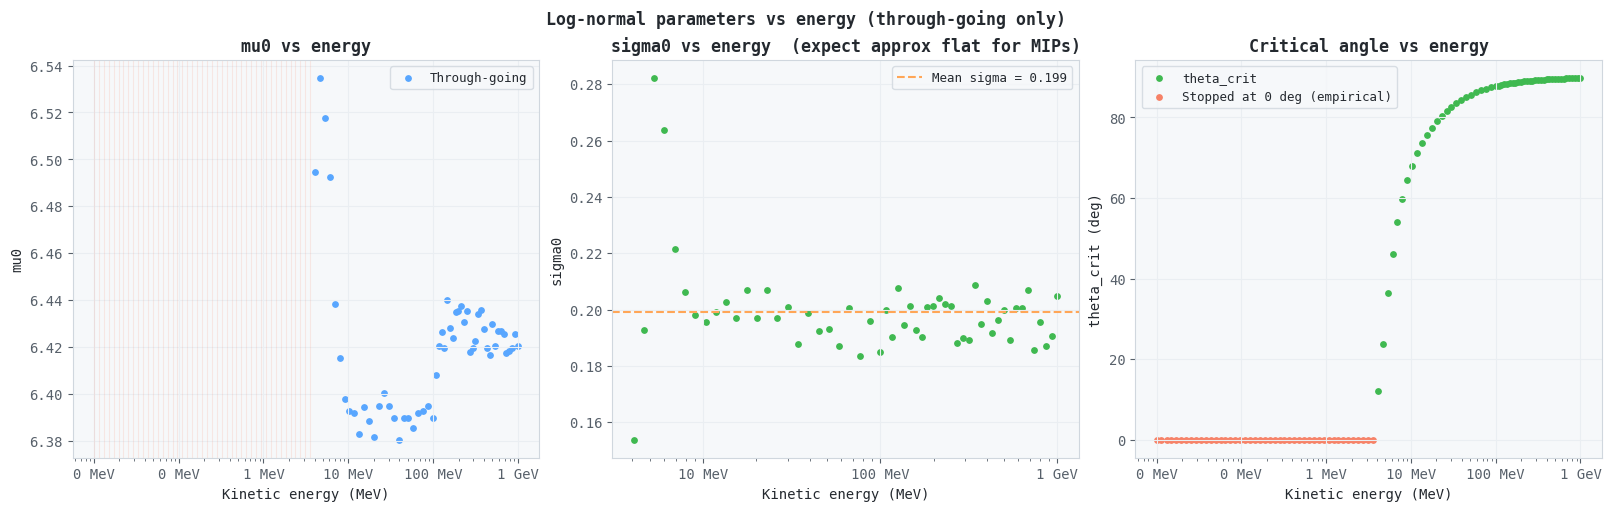

In [23]:
# ── Diagnostic: mu0 and sigma0 vs energy ─────────────────────────────────────
T    = energy_table
tg   = [r for r in T if r['model'] == 'lognormal']
st   = [r for r in T if r['model'] == 'empirical']

E_tg      = np.array([r['energy_MeV']     for r in tg])
mu0_tg    = np.array([r['mu0']            for r in tg])
sigma0_tg = np.array([r['sigma0']         for r in tg])
tc_tg     = np.array([r['theta_crit_deg'] for r in tg])
E_st      = np.array([r['energy_MeV']     for r in st])

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
fig.suptitle('Log-normal parameters vs energy (through-going only)',
             fontsize=12, fontweight='bold')

ax = axes[0]
ax.scatter(E_tg, mu0_tg, color='#58a6ff', s=15, label='Through-going')
for e in E_st:
    ax.axvline(e, color='#f78166', alpha=0.15, linewidth=0.8)
ax.set_xscale('log')
ax.set_xlabel('Kinetic energy (MeV)')
ax.set_ylabel('mu0')
ax.set_title('mu0 vs energy', fontweight='bold')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f'{x/1000:.0f} GeV' if x >= 1000 else f'{x:.0f} MeV'))
ax.legend(fontsize=9)

ax = axes[1]
ax.scatter(E_tg, sigma0_tg, color='#3fb950', s=15)
if len(sigma0_tg):
    ax.axhline(sigma0_tg.mean(), color='#ffa657', linestyle='--', linewidth=1.5,
               label=f'Mean sigma = {sigma0_tg.mean():.3f}')
ax.set_xscale('log')
ax.set_xlabel('Kinetic energy (MeV)')
ax.set_ylabel('sigma0')
ax.set_title('sigma0 vs energy  (expect approx flat for MIPs)', fontweight='bold')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f'{x/1000:.0f} GeV' if x >= 1000 else f'{x:.0f} MeV'))
ax.legend(fontsize=9)

ax = axes[2]
ax.scatter(E_tg, tc_tg, color='#3fb950', s=15, label='theta_crit')
ax.scatter(E_st, np.zeros(len(E_st)), color='#f78166', s=15,
           label='Stopped at 0 deg (empirical)')
ax.set_xscale('log')
ax.set_xlabel('Kinetic energy (MeV)')
ax.set_ylabel('theta_crit (deg)')
ax.set_title('Critical angle vs energy', fontweight='bold')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f'{x/1000:.0f} GeV' if x >= 1000 else f'{x:.0f} MeV'))
ax.legend(fontsize=9)

plt.savefig(os.path.join(SWEEP_DIR, 'lognormal_params_vs_energy.png'),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
print('Saved: lognormal_params_vs_energy.png')
plt.show()


Saved: example_lognormal_fits.png


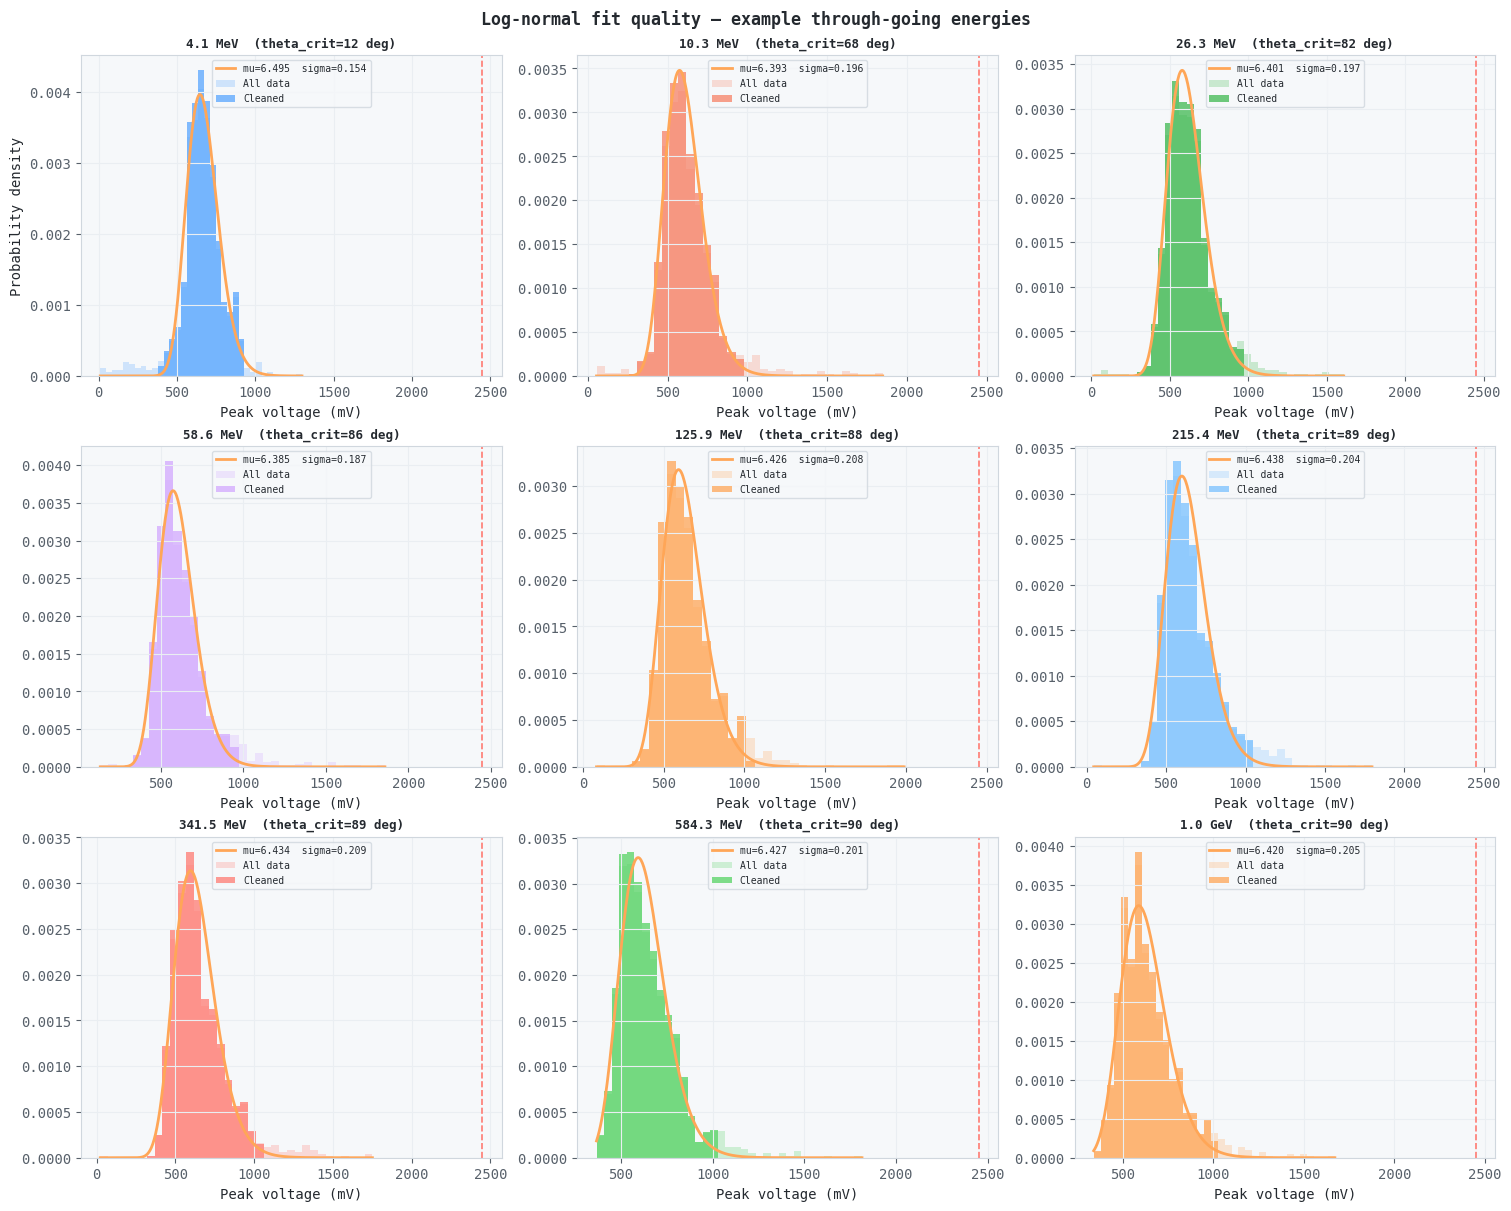

In [25]:
# ── Example fits: sample of through-going energies ───────────────────────────
N_EXAMPLES = 9   # number of panels — must be divisible by 3

tg_entries = [r for r in energy_table
              if r['model'] == 'lognormal' and '_pv_clean' in r]

idx_picks = np.round(np.linspace(0, len(tg_entries) - 1, N_EXAMPLES)).astype(int)
picks     = [tg_entries[i] for i in idx_picks]

ncols = 3
nrows = int(np.ceil(N_EXAMPLES / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows),
                          constrained_layout=True)
fig.suptitle('Log-normal fit quality — example through-going energies',
             fontsize=12, fontweight='bold')
axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

PALETTE = ['#58a6ff','#f78166','#3fb950','#d2a8ff','#ffa657',
           '#79c0ff','#ff7b72','#56d364','#ffa657']

for ax, entry, col in zip(axes_flat, picks, PALETTE):
    pv    = entry['_peak_v']
    pv_cl = entry['_pv_clean']
    mu0   = entry['mu0']
    sig0  = entry['sigma0']
    e_mev = entry['energy_MeV']
    tc    = entry['theta_crit_deg']

    counts_all, edges = np.histogram(pv, bins=35, density=True)
    centres = (edges[:-1] + edges[1:]) / 2
    width   = edges[1] - edges[0]
    x_plot  = np.linspace(edges[0], edges[-1], 400)

    ax.bar(centres, counts_all, width=width, color=col, alpha=0.25,
           edgecolor='none', label='All data')
    counts_cl, _ = np.histogram(pv_cl, bins=edges, density=True)
    ax.bar(centres, counts_cl, width=width, color=col, alpha=0.75,
           edgecolor='none', label='Cleaned')
    pdf = lognorm.pdf(x_plot, s=sig0, scale=np.exp(mu0))
    ax.plot(x_plot, pdf, color='#ffa657', linewidth=2,
            label=f'mu={mu0:.3f}  sigma={sig0:.3f}')
    ax.axvline(DISCRIMINATOR_THRESHOLD_MV, color='#ff7b72',
               linestyle='--', linewidth=1.2)

    e_label = f'{e_mev/1000:.1f} GeV' if e_mev >= 1000 else f'{e_mev:.1f} MeV'
    ax.set_title(f'{e_label}  (theta_crit={tc:.0f} deg)', fontweight='bold', fontsize=9)
    ax.set_xlabel('Peak voltage (mV)')
    ax.legend(fontsize=7)

axes_flat[0].set_ylabel('Probability density')
for ax in axes_flat[len(picks):]:
    ax.set_visible(False)

plt.savefig(os.path.join(SWEEP_DIR, 'example_lognormal_fits.png'),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
print('Saved: example_lognormal_fits.png')
plt.show()


In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# HISTOGRAM-SHIFT LUT — write and query functions
#
# Storage model:
#   Every energy point stores its full 0° peak-voltage histogram.
#   At query time the histogram is shifted on a log scale by the
#   1/cos(θ) factor (equivalent to multiplying all voltages by 1/cos θ).
#
#   Stopped   (is_stopped=True)  → no shift at any angle
#   Through-going (is_stopped=False) → shift by 1/cos(θ) for θ ≤ θ_crit,
#                                      shift by 1/cos(θ_crit) for θ > θ_crit
#
# Why log-scale shift?
#   The peak voltage V ∝ n_photons ∝ path_length ∝ 1/cos θ.
#   On a linear scale this is a multiplicative shift, which on a log scale
#   becomes an additive shift: ln(V(θ)) = ln(V₀) + ln(1/cos θ).
#   Shifting the log-bin-centres by ln(1/cos θ) and exponentiating back
#   gives the predicted histogram at angle θ without refitting anything.
# ═══════════════════════════════════════════════════════════════════════════

import json, os, re as _re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


# ── WRITE ─────────────────────────────────────────────────────────────────────

def write_lut(energy_table, sweep_dir, particle_tag,
              scint_yield, scint_thickness_mm,
              stop_fraction_threshold, hist_bins,
              outlier_k):
    """
    Write the lookup table to a JSON file.

    Each entry stores the full 0° peak-voltage histogram as
    (bin_edges_mV, counts) so the exact simulated shape is preserved.
    Counts are stored as integers (not density) so they can be trivially
    resampled with np.repeat or used to reconstruct a CDF.

    Returns the path to the written file.
    """
    out_json = os.path.join(sweep_dir, f'pmt_lut_{particle_tag}.json')

    entries = []
    for r in energy_table:
        pv = r['_peak_v']

        # Build histogram with consistent edges across all energies
        # Use log-spaced edges so the shift later is uniform in log space
        pv_pos = pv[pv > 0]
        log_edges = np.linspace(np.log(pv_pos.min()),
                                np.log(pv_pos.max()),
                                hist_bins + 1)
        edges_mV  = np.exp(log_edges)
        counts, _ = np.histogram(pv_pos, bins=edges_mV)

        entry = {
            'energy_MeV':      r['energy_MeV'],
            'is_stopped':      r['is_stopped'],
            'stop_frac':       round(r['stop_frac'],       4),
            'theta_crit_deg':  round(r['theta_crit_deg'],  3),
            # Histogram at θ = 0°
            'bin_edges_mV':    [round(float(e), 4) for e in edges_mV],
            'counts':          counts.tolist(),          # integers
            # Convenience statistics computed from the raw distribution
            'mean_mV':         round(float(pv_pos.mean()),         4),
            'std_mV':          round(float(pv_pos.std()),          4),
            'median_mV':       round(float(np.median(pv_pos)),     4),
            'n_events':        int(len(pv_pos)),
        }
        entries.append(entry)

    lut = {
        'metadata': {
            'particle':               particle_tag,
            'scint_yield':            scint_yield,
            'scint_thickness_mm':     scint_thickness_mm,
            'stop_fraction_threshold': stop_fraction_threshold,
            'hist_bins':              hist_bins,
            'outlier_k':              outlier_k,
            'shift_model': (
                'Multiplicative voltage shift: V(theta) = V(0) * scale(theta)  '
                'where scale = 1/cos(theta)        for theta <= theta_crit_deg  '
                '      scale = 1/cos(theta_crit)   for theta >  theta_crit_deg  '
                '      scale = 1                   for stopped particles'
            ),
        },
        'entries': entries,
    }

    with open(out_json, 'w') as f:
        json.dump(lut, f, indent=2)

    print(f'Saved: {out_json}')
    print(f'  {len(entries)} entries  |  '
          f'{sum(1 for e in entries if e["is_stopped"])} stopped  |  '
          f'{sum(1 for e in entries if not e["is_stopped"])} through-going')
    return out_json


# Call it
_m = _re.search(r'energy_sweep_([^_]+)_', SWEEP_DIR)
PARTICLE_TAG = _m.group(1) if _m else 'unknown'

OUT_JSON = write_lut(
    energy_table          = energy_table,
    sweep_dir             = SWEEP_DIR,
    particle_tag          = PARTICLE_TAG,
    scint_yield           = SCINT_YIELD,
    scint_thickness_mm    = SCINT_THICKNESS,
    stop_fraction_threshold = STOP_FRACTION_THRESHOLD,
    hist_bins             = 100,
    outlier_k             = OUTLIER_K,
)

NameError: name 'energy_table' is not defined

In [7]:
# ── QUERY ─────────────────────────────────────────────────────────────────────
_m = _re.search(r'energy_sweep_([^_]+)_', SWEEP_DIR)
PARTICLE_TAG = _m.group(1) if _m else 'unknown'

def query_lut(particle, energy_MeV, theta_deg, lut_path,
              threshold_mV, plot=False, seed=0):
    """
    Query the PMT lookup table and return the detection probability.

    Parameters
    ----------
    particle     : str   — particle name, used only for plot title
    energy_MeV   : float — kinetic energy [MeV]
    theta_deg    : float — angle of incidence [degrees, 0 = perpendicular]
    lut_path     : str   — path to the JSON file written by write_lut()
    threshold_mV : float — discriminator threshold [mV]
    plot         : bool  — if True, show the shifted histogram plot
    seed         : int   — random seed for reproducibility

    Returns
    -------
    detection_prob : float — fraction of distribution above threshold_mV
    """
    with open(lut_path) as f:
        lut = json.load(f)

    entries  = lut['entries']
    energies = np.array([e['energy_MeV'] for e in entries])

    # ── Find bracketing energy entries ────────────────────────────────────────
    idx   = np.clip(np.searchsorted(energies, energy_MeV), 1, len(energies) - 1)
    e_lo  = entries[idx - 1]
    e_hi  = entries[idx]

    # Log-linear interpolation weight towards upper entry
    log_e    = np.log(np.clip(energy_MeV, energies[0], energies[-1]))
    log_e_lo = np.log(e_lo['energy_MeV'])
    log_e_hi = np.log(e_hi['energy_MeV'])
    w = ((log_e - log_e_lo) / (log_e_hi - log_e_lo)
         if log_e_hi > log_e_lo else 0.5)

    # ── Sampling helper ───────────────────────────────────────────────────────
    rng = np.random.default_rng(seed=seed)

    def _sample(entry, theta_d, n):
        edges  = np.array(entry['bin_edges_mV'])
        counts = np.array(entry['counts'], dtype=float)
        tc     = entry['theta_crit_deg']

        if entry['is_stopped']:
            scale = 1.0
        elif theta_d <= tc:
            scale = 1.0 / np.cos(np.radians(theta_d))
        else:
            scale = 1.0 / np.cos(np.radians(tc))

        shifted_edges = edges * scale
        probs         = counts / counts.sum()
        bin_idx       = rng.choice(len(probs), size=n, p=probs)
        lo = shifted_edges[:-1][bin_idx]
        hi = shifted_edges[1:][bin_idx]
        return lo + rng.random(n) * (hi - lo)

    # ── Draw 100k samples for a smooth probability estimate ───────────────────
    N_PROB = 100_000
    n_lo   = int(round((1 - w) * N_PROB))
    n_hi   = N_PROB - n_lo
    samples = np.concatenate([
        _sample(e_lo, theta_deg, n_lo),
        _sample(e_hi, theta_deg, n_hi),
    ])

    detection_prob = float((samples >= threshold_mV).mean())

    # ── Optional plot ─────────────────────────────────────────────────────────
    if plot:
        e_label = (f'{energy_MeV/1000:.1f} GeV'
                   if energy_MeV >= 1000 else f'{energy_MeV:.1f} MeV')
        regime  = ('stopped'       if     e_lo['is_stopped'] and     e_hi['is_stopped']
                   else 'through-going' if not e_lo['is_stopped'] and not e_hi['is_stopped']
                   else 'mixed')

        # Subsample for the plot — 10k is plenty for a smooth histogram
        plot_samples                   = samples[:10_000]
        counts_plot, bin_edges_plot    = np.histogram(plot_samples, bins=50)
        bin_centers                    = (bin_edges_plot[:-1] + bin_edges_plot[1:]) / 2
        width                          = bin_edges_plot[1] - bin_edges_plot[0]
        colors                         = np.where(bin_centers < threshold_mV,
                                                   '#f78166', '#3fb950')

        fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
        ax.bar(bin_centers, counts_plot, width=width,
               color=colors, edgecolor='none')
        ax.axvline(threshold_mV, color='#ffa657', linestyle='--', linewidth=2)
        ax.legend(handles=[
            Patch(facecolor='#3fb950', label='Above threshold (triggered)'),
            Patch(facecolor='#f78166', label='Below threshold (rejected)'),
            Line2D([0], [0], color='#ffa657', linestyle='--', linewidth=2,
                   label=f'Threshold = {threshold_mV:.1f} mV'),
        ], fontsize=9)
        ax.set_xlabel('Peak voltage (mV)')
        ax.set_ylabel('Counts')
        ax.set_title(
            f'PMT response — {particle}  {e_label}  '
            f'θ={theta_deg:.0f}°  ({regime})',
            fontweight='bold',
        )
        ax.text(0.98, 0.95,
                f'Detection prob: {detection_prob*100:.1f}%',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=10, color='#e6edf3',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#21262d',
                          edgecolor='#30363d'))
        plt.show()

    return detection_prob


# ── Quick validation ───────────────────────────────────────────────────────────
DISCRIMINATOR_THRESHOLD_MV = 1000
print('Detection probability examples:')
print(f'  {"Particle":<8} {"E":>10}  {"theta":>6}  {"prob":>8}')
print('-' * 40)
for E_q, th_q in [(50, 0), (500, 0), (500, 45), (5000, 0),
                  (5000, 60), (50000, 0), (50000, 75)]:
    prob = query_lut(PARTICLE_TAG, E_q, th_q,
                     OUT_JSON, DISCRIMINATOR_THRESHOLD_MV)
    e_label = f'{E_q/1000:.0f} GeV' if E_q >= 1000 else f'{E_q} MeV'
    print(f'  {PARTICLE_TAG:<8} {e_label:>10}  {th_q:>5}°  {prob*100:>7.1f}%')
 
# Show one plot example
print()
#print('Plot example: 1 GeV, theta=30°')
_ = query_lut(PARTICLE_TAG, 20, 50,
              OUT_JSON, DISCRIMINATOR_THRESHOLD_MV, plot=True)

Detection probability examples:
  Particle          E   theta      prob
----------------------------------------


NameError: name 'OUT_JSON' is not defined